# Anomaly Detection Analysis
Hardcoded configuration and full pipeline execution.

In [70]:
%matplotlib inline
import sys
import Data.pytorch_autoencoder as pytorch_autoencoder
sys.modules["pytorch_autoencoder"] = pytorch_autoencoder
from Data.anomaly_detection import detect_anomalies, detect_using_isolation_forest, detect_using_one_class_support_vector_machine, add_synthetic_anomalies
from Data.autoencoder_data_preparation import read_and_prepare_data
import tabulate
import os
import pandas as pd
import numpy as np
from collections import defaultdict
import random
import atexit
import json
import re
from openpyxl import Workbook
from openpyxl.styles import Font, Alignment, PatternFill, Border, Side
import matplotlib.pyplot as plt

STORE = True
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

def seed_everything(seed=RANDOM_SEED):
    # Reset RNG state for reproducible notebook runs.
    random.seed(seed)
    np.random.seed(seed)
    if hasattr(pytorch_autoencoder, "set_random_seed"):
        pytorch_autoencoder.set_random_seed(seed)

seed_everything(RANDOM_SEED)


def extract_event_column_indices(column_names):
    """Return indices and clean event names for one-hot encoded event columns."""
    event_columns = []
    for idx, name in enumerate(column_names):
        name_str = str(name)
        lower_name = name_str.lower()
        if "event" in lower_name:
            pos = lower_name.find("event")
            event_name = name_str[pos + len("event"):].strip(" _-:\t")
            if not event_name:
                event_name = name_str
            event_columns.append((idx, event_name))
    return event_columns


def get_event_for_row(row_values, event_columns):
    """Resolve the event name from one-hot encoded event values for one row."""
    if not event_columns:
        return "UNKNOWN_EVENT"

    active_events = [event_name for col_idx, event_name in event_columns if row_values[col_idx] > 0.5]
    if len(active_events) == 1:
        return active_events[0]

    # Fallback for non-binary/scaled values: use the event column with highest value.
    best_col_idx, best_event_name = max(event_columns, key=lambda col: row_values[col[0]])
    if row_values[best_col_idx] <= 0:
        return "UNKNOWN_EVENT"
    return best_event_name


def to_numpy_2d(array_like):
    """Convert tensor/array-like input to a 2D NumPy array for sklearn."""
    if hasattr(array_like, "detach"):
        array_like = array_like.detach()
    if hasattr(array_like, "cpu"):
        array_like = array_like.cpu()
    if hasattr(array_like, "numpy"):
        array_like = array_like.numpy()

    arr = np.asarray(array_like)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
    elif arr.ndim > 2:
        arr = np.squeeze(arr)
        if arr.ndim != 2:
            raise ValueError(f"Expected 2D array for inverse scaling, got shape {arr.shape}")
    return arr

In [71]:
# Hardcoded configuration (edit as needed)
all_resources = ["hbw_1", "hbw_2", "mm_1", "sm_1", "wt_2", "ov_1", "vgr_1", "ov_2", "mm_2", "dm_2", "pm_1", "wt_1", "sm_2", "vgr_2", "hw_1"]
resources = all_resources
# True = load preprepared data, False = read and prepare from scratch.
reread_prepared_data = True
retrain_AE = False
redo_hyperparameter_tuning = False

## Run Pipeline
Load data, inject anomalies, and run all models to build `all_results`.

In [72]:
# Re-seed before running the pipeline to keep outputs deterministic.
seed_everything(RANDOM_SEED)

tables_dir = "tables"
if STORE:
    os.makedirs(tables_dir, exist_ok=True)

all_results = {}

for resource in resources:
    # Get the data
    print(
        f"Performing Anomaly detection on resource {resource}...\n\n"
        + ("Loading preprepared data...\n" if reread_prepared_data else "Reading and preparing data...\n")
    )
    train_scaled, val_scaled, test_scaled, scaling, column_names = read_and_prepare_data(
        resource,
        load_preprepared=reread_prepared_data,
        prints=False,
    )

    test_anomalous, anomalous_values, anomaly_types = add_synthetic_anomalies(
        test_scaled,
        train_scaled,
        val_scaled,
        column_names,
    )

    # Perform anomaly detection on the data
    print("Performing anomaly detection on the data...\n")
    detected_rows, reconstructions, threshold = detect_anomalies(
        train_scaled,
        val_scaled,
        test_anomalous,
        scaling,
        column_names,
        resource,
        train_model=retrain_AE,
        redo_hyperparameter_tuning=redo_hyperparameter_tuning,
        prints=True,
        test_scaled=test_scaled,
    )

    # Perform anomaly detection on the data using baseline models for comparison
    print("Performing anomaly detection using baseline techniques...\n")
    if_detected_rows = detect_using_isolation_forest(
        train_scaled,
        val_scaled,
        test_anomalous,
        scaling,
        column_names,
        prints=True,
    )
    svm_detected_rows = detect_using_one_class_support_vector_machine(
        train_scaled,
        test_anomalous,
        test_scaled,
        scaling,
        column_names,
        prints=True,
    )

    all_results[resource] = {
        "train_scaled": train_scaled,
        "val_scaled": val_scaled,
        "test_anomalous": test_anomalous,
        "anomalous_values": anomalous_values,  # Dict with row as id and the value is a numpy array containing the anomalous column-IDs
        "ae_detected": detected_rows,
        "if_detected": if_detected_rows,
        "svm_detected": svm_detected_rows,
        "column_names": column_names,
        "ae_reconstructions": reconstructions,
        "scaling": scaling,
        "ae_threshold": threshold,
        "anomaly_types": anomaly_types,
    }

Performing Anomaly detection on resource hbw_1...

Loading preprepared data...

Performing anomaly detection on the data...

Performing anomaly detection on the modified test set...

Performing anomaly detection using baseline techniques...

Performing Anomaly detection on resource hbw_2...

Loading preprepared data...

Performing anomaly detection on the data...

Performing anomaly detection on the modified test set...

Performing anomaly detection using baseline techniques...

Performing Anomaly detection on resource mm_1...

Loading preprepared data...

Performing anomaly detection on the data...

Performing anomaly detection on the modified test set...

Performing anomaly detection using baseline techniques...

Performing Anomaly detection on resource sm_1...

Loading preprepared data...

Performing anomaly detection on the data...

Performing anomaly detection on the modified test set...

Performing anomaly detection using baseline techniques...

Performing Anomaly detection on re

## Metrics Per Resource
Compute precision/recall/F1 per resource for each model.

In [73]:
methods = [
    ("Autoencoder", "ae_detected"),
    ("Isolation Forest", "if_detected"),
    ("SVM", "svm_detected"),
]

for method_name, method_key in methods:
    print(f"\n{'='*60}")
    print(f"Results for {method_name}")
    print(f"{'='*60}\n")

    results_table = []
    for resource, data in all_results.items():
        anomalous_values = data["anomalous_values"]
        train_rows = len(data["train_scaled"])
        test_rows = len(data["test_anomalous"])
        detected_rows = data[method_key]

        detected_set = set(detected_rows) if not isinstance(detected_rows, dict) else set(detected_rows.keys())
        tp = sum(1 for row_id in detected_set if row_id in anomalous_values)
        fp = sum(1 for row_id in detected_set if row_id not in anomalous_values)
        fn = sum(1 for row_id in anomalous_values.keys() if row_id not in detected_set)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

        results_table.append([
            resource,
            train_rows,
            test_rows,
            f"{precision:.3f}",
            f"{recall:.3f}",
            f"{f1:.3f}",
        ])

    results_headers = ["Resource", "Train Rows", "Val Rows", "Precision", "Recall", "F1-Score"]
    print(tabulate.tabulate(results_table, headers=results_headers))

    if STORE:
        # Store each per-method table in the tables folder.
        method_file_name = method_key.replace("_detected", "") + "_per_resource_metrics.xlsx"
        method_output_path = os.path.join(tables_dir, method_file_name)
        pd.DataFrame(results_table, columns=results_headers).to_excel(method_output_path, index=False)


Results for Autoencoder

Resource      Train Rows    Val Rows    Precision    Recall    F1-Score
----------  ------------  ----------  -----------  --------  ----------
hbw_1              41365        5171        0.67      0.485       0.562
hbw_2              77907        9738        0.737     0.561       0.637
mm_1                8563        1070        0.81      0.63        0.708
sm_1                8144        1018        0.6       0.346       0.439
wt_2               23529        2941        0.794     0.73        0.761
ov_1               27607        3451        0.741     0.69        0.714
vgr_1              68280        8535        0.628     0.402       0.49
ov_2               14596        1825        0.778     0.761       0.769
mm_2                6568         821        0.364     0.19        0.25
dm_2                4614         577        0.889     0.533       0.667
pm_1                7432         929        0.722     0.542       0.619
wt_1               28126        3516    

## Combined Metrics Across Resources
Aggregate precision/recall/F1 over all resources.

In [74]:
print(f"\n{'='*60}")
print("Combined Results Across All Resources")
print(f"{'='*60}\n")

combined_table = []
for method_name, method_key in methods:
    total_tp = 0
    total_fp = 0
    total_fn = 0

    for resource, data in all_results.items():
        anomalous_values = data["anomalous_values"]
        detected_rows = data[method_key]

        detected_set = set(detected_rows) if not isinstance(detected_rows, dict) else set(detected_rows.keys())
        total_tp += sum(1 for row_id in detected_set if row_id in anomalous_values)
        total_fp += sum(1 for row_id in detected_set if row_id not in anomalous_values)
        total_fn += sum(1 for row_id in anomalous_values.keys() if row_id not in detected_set)

    combined_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    combined_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    combined_f1 = 2 * (combined_precision * combined_recall) / (combined_precision + combined_recall) if (combined_precision + combined_recall) > 0 else 0

    combined_table.append([
        method_name,
        f"{combined_precision:.3f}",
        f"{combined_recall:.3f}",
        f"{combined_f1:.3f}",
    ])

combined_headers = ["Method", "Precision", "Recall", "F1-Score"]
combined_table_text = tabulate.tabulate(combined_table, headers=combined_headers)
print(combined_table_text)

if STORE:
    combined_table_output_path = os.path.join(tables_dir, "combined_metrics.xlsx")
    pd.DataFrame(combined_table, columns=combined_headers).to_excel(combined_table_output_path, index=False)


Combined Results Across All Resources

Method              Precision    Recall    F1-Score
----------------  -----------  --------  ----------
Autoencoder             0.717     0.571       0.636
Isolation Forest        0.069     0.433       0.12
SVM                     0.014     0.007       0.01


## Metrics Per Anomaly Type
Recall per anomaly type across all resources.

In [75]:
print(f"\n{'='*60}")
print("Results Per Anomaly Type")
print(f"{'='*60}\n")

for method_name, method_key in methods:
    print(f"\n{'-'*60}")
    print(f"{method_name}")
    print(f"{'-'*60}\n")

    anomaly_type_tp = defaultdict(int)
    anomaly_type_fn = defaultdict(int)
    anomaly_type_count = defaultdict(int)

    for resource, data in all_results.items():
        anomaly_types = data["anomaly_types"]
        detected_rows = data[method_key]
        detected_set = set(detected_rows) if not isinstance(detected_rows, dict) else set(detected_rows.keys())

        for row_id, anomaly_type in anomaly_types.items():
            anomaly_type_count[anomaly_type] += 1
            if row_id in detected_set:
                anomaly_type_tp[anomaly_type] += 1
            else:
                anomaly_type_fn[anomaly_type] += 1

    per_anomaly_table = []
    all_anomaly_types = set(anomaly_type_tp.keys()) | set(anomaly_type_fn.keys()) | set(anomaly_type_count.keys())

    for anomaly_type in sorted(all_anomaly_types):
        tp = anomaly_type_tp[anomaly_type]
        fn = anomaly_type_fn[anomaly_type]
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        per_anomaly_table.append([anomaly_type, anomaly_type_count[anomaly_type], tp, fn, f"{recall:.3f}"])

    per_anomaly_headers = ["Anomaly Type", "Count", "TP", "FN", "Recall"]
    print(tabulate.tabulate(per_anomaly_table, headers=per_anomaly_headers))

    if STORE:
        method_file_name = method_key.replace("_detected", "") + "_per_anomaly_type_metrics.xlsx"
        method_output_path = os.path.join(tables_dir, method_file_name)
        pd.DataFrame(per_anomaly_table, columns=per_anomaly_headers).to_excel(method_output_path, index=False)


Results Per Anomaly Type


------------------------------------------------------------
Autoencoder
------------------------------------------------------------

Anomaly Type      Count    TP    FN    Recall
--------------  -------  ----  ----  --------
context             627   308   319     0.491
data_point          620   404   216     0.652

------------------------------------------------------------
Isolation Forest
------------------------------------------------------------

Anomaly Type      Count    TP    FN    Recall
--------------  -------  ----  ----  --------
context             627   316   311     0.504
data_point          620   224   396     0.361

------------------------------------------------------------
SVM
------------------------------------------------------------

Anomaly Type      Count    TP    FN    Recall
--------------  -------  ----  ----  --------
context             627     4   623     0.006
data_point          620     5   615     0.008


## Metrics Per Number of Anomalies in a Row
Recall and miss rate by anomaly count per row.

In [76]:
print(f"\n{'='*60}")
print("Results Per Number of Anomalies in a Row")
print(f"{'='*60}\n")

for method_name, method_key in methods:
    print(f"\n{'-'*60}")
    print(f"{method_name}")
    print(f"{'-'*60}\n")

    anomalies_per_row_tp = defaultdict(int)
    anomalies_per_row_fn = defaultdict(int)
    anomalies_per_row_count = defaultdict(int)

    for resource, data in all_results.items():
        anomalous_values = data["anomalous_values"]
        detected_rows = data[method_key]
        detected_set = set(detected_rows) if not isinstance(detected_rows, dict) else set(detected_rows.keys())

        for row_id, anomaly_columns in anomalous_values.items():
            anomaly_count = int(np.asarray(anomaly_columns).reshape(-1).size)
            anomalies_per_row_count[anomaly_count] += 1

            if row_id in detected_set:
                anomalies_per_row_tp[anomaly_count] += 1
            else:
                anomalies_per_row_fn[anomaly_count] += 1

    per_row_anomaly_table = []
    all_anomaly_counts = sorted(
        set(anomalies_per_row_count.keys())
        | set(anomalies_per_row_tp.keys())
        | set(anomalies_per_row_fn.keys())
    )

    for anomaly_count in all_anomaly_counts:
        tp = anomalies_per_row_tp[anomaly_count]
        fn = anomalies_per_row_fn[anomaly_count]
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        miss_rate = fn / (tp + fn) if (tp + fn) > 0 else 0

        per_row_anomaly_table.append([
            anomaly_count,
            anomalies_per_row_count[anomaly_count],
            tp,
            fn,
            f"{recall:.3f}",
            f"{miss_rate:.3f}",
        ])

    per_row_anomaly_headers = ["# Anomalies in Row", "Count", "TP", "FN", "Recall", "Miss Rate"]
    print(tabulate.tabulate(per_row_anomaly_table, headers=per_row_anomaly_headers))

    if STORE:
        method_file_name = method_key.replace("_detected", "") + "_per_row_anomaly_count_metrics.xlsx"
        method_output_path = os.path.join(tables_dir, method_file_name)
        pd.DataFrame(per_row_anomaly_table, columns=per_row_anomaly_headers).to_excel(method_output_path, index=False)


Results Per Number of Anomalies in a Row


------------------------------------------------------------
Autoencoder
------------------------------------------------------------

  # Anomalies in Row    Count    TP    FN    Recall    Miss Rate
--------------------  -------  ----  ----  --------  -----------
                   1      515   209   306     0.406        0.594
                   2      399   242   157     0.607        0.393
                   3      333   261    72     0.784        0.216

------------------------------------------------------------
Isolation Forest
------------------------------------------------------------

  # Anomalies in Row    Count    TP    FN    Recall    Miss Rate
--------------------  -------  ----  ----  --------  -----------
                   1      515   141   374     0.274        0.726
                   2      399   206   193     0.516        0.484
                   3      333   193   140     0.58         0.42

------------------------------

## Combined Confusion Matrix Counts
Raw TP/FP/TN/FN counts aggregated across resources.

In [77]:
total_test_rows = sum(len(data["test_anomalous"]) for data in all_results.values())
confusion_counts = {"TP": {}, "FP": {}, "TN": {}, "FN": {}}
confusion_headers = ["Count", "Autoencoder", "Isolation Forest", "SVM"]
confusion_output_path = os.path.join(tables_dir, "combined_confusion_matrix_counts.xlsx")

def _store_confusion_matrix_counts():
    if not STORE:
        return

    rows = [
        [
            count_name,
            confusion_counts[count_name].get("Autoencoder", 0),
            confusion_counts[count_name].get("Isolation Forest", 0),
            confusion_counts[count_name].get("SVM", 0),
        ]
        for count_name in ["TP", "FP", "TN", "FN"]
    ]
    pd.DataFrame(rows, columns=confusion_headers).to_excel(confusion_output_path, index=False)

atexit.register(_store_confusion_matrix_counts)

for method_name, method_key in methods:
    total_tp = 0
    total_fp = 0
    total_fn = 0

    for resource, data in all_results.items():
        anomalous_values = data["anomalous_values"]
        detected_rows = data[method_key]
        detected_set = set(detected_rows) if not isinstance(detected_rows, dict) else set(detected_rows.keys())

        total_tp += sum(1 for row_id in detected_set if row_id in anomalous_values)
        total_fp += sum(1 for row_id in detected_set if row_id not in anomalous_values)
        total_fn += sum(1 for row_id in anomalous_values.keys() if row_id not in detected_set)

    total_tn = total_test_rows - total_tp - total_fp - total_fn
    confusion_counts["TP"][method_name] = total_tp
    confusion_counts["FP"][method_name] = total_fp
    confusion_counts["TN"][method_name] = total_tn
    confusion_counts["FN"][method_name] = total_fn

confusion_rows = [
    [
        count_name,
        confusion_counts[count_name].get("Autoencoder", 0),
        confusion_counts[count_name].get("Isolation Forest", 0),
        confusion_counts[count_name].get("SVM", 0),
    ]
    for count_name in ["TP", "FP", "TN", "FN"]
]
print("\nConfusion Matrices (Combined, Raw Counts)")
print(tabulate.tabulate(confusion_rows, headers=confusion_headers))

if STORE:
    combined_output_path = os.path.join(tables_dir, "combined_metrics.xlsx")
    pd.DataFrame(combined_table, columns=combined_headers).to_excel(combined_output_path, index=False)


Confusion Matrices (Combined, Raw Counts)
Count      Autoencoder    Isolation Forest    SVM
-------  -------------  ------------------  -----
TP                 712                 540      9
FP                 281                7230    630
TN               48052               41103  47703
FN                 535                 707   1238


## F1 Score Correlations (Autoencoder)
Scatter plots for F1 vs columns, training rows, and event count.

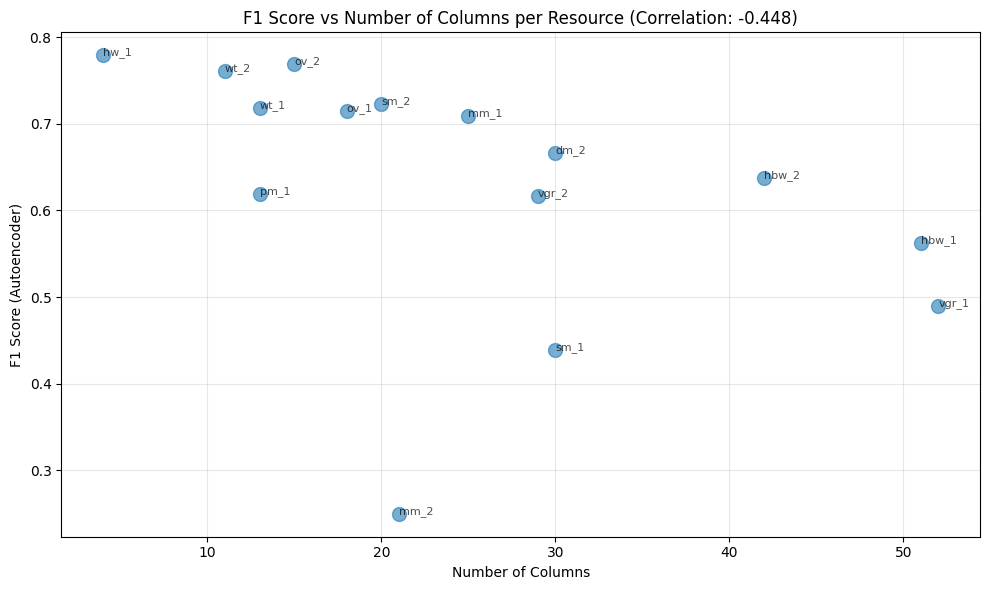

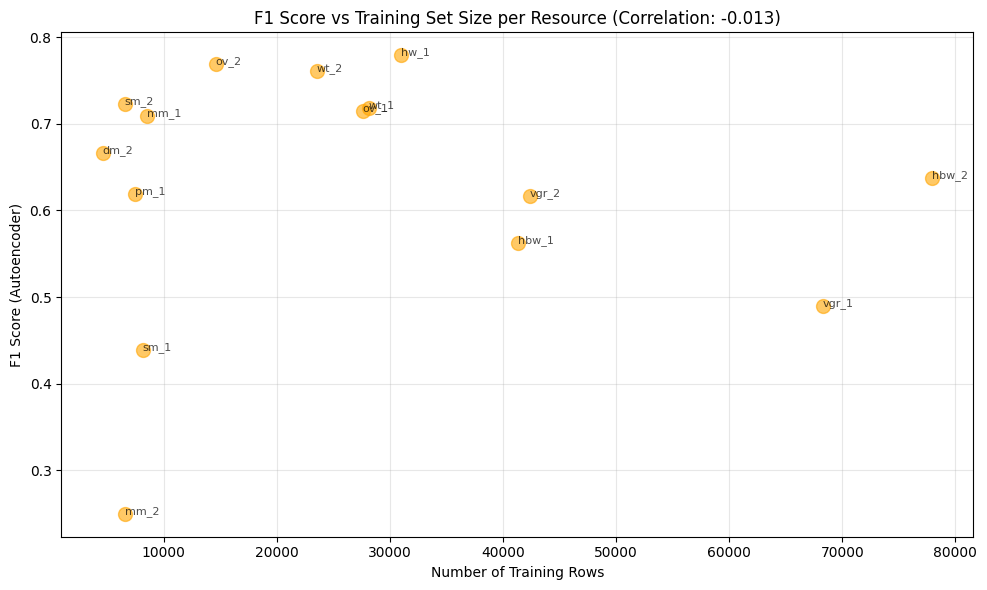

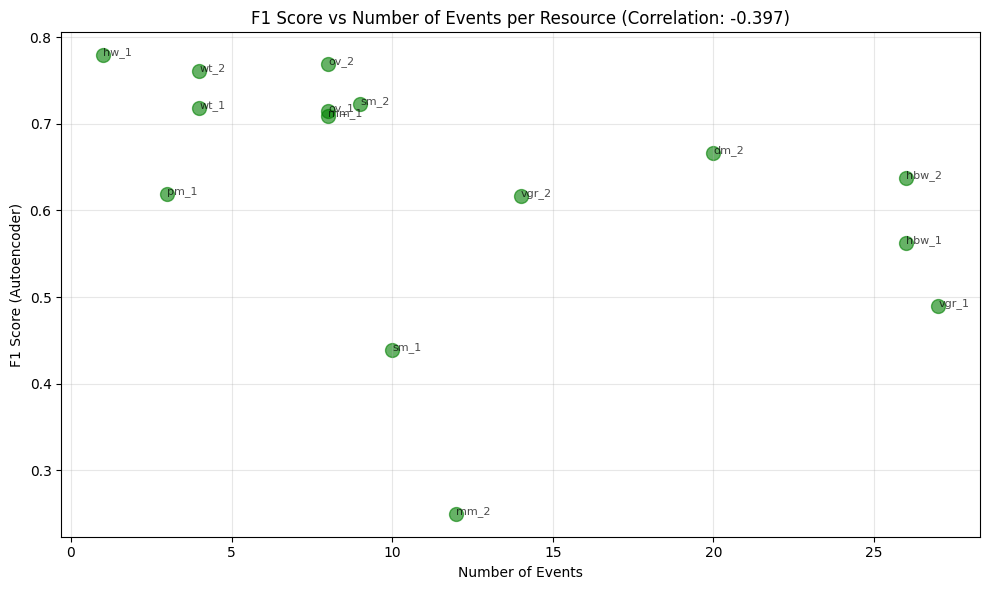

In [78]:
import matplotlib.pyplot as plt

# Extract F1 scores and column counts per resource
resources_list = []
f1_scores = []
column_counts = []

for resource, data in all_results.items():
    resources_list.append(resource)
    column_counts.append(len(data["column_names"]))

    # Calculate F1 score for autoencoder for this resource
    anomalous_values = data["anomalous_values"]
    detected_rows = data["ae_detected"]
    detected_set = set(detected_rows) if not isinstance(detected_rows, dict) else set(detected_rows.keys())

    tp = sum(1 for row_id in detected_set if row_id in anomalous_values)
    fp = sum(1 for row_id in detected_set if row_id not in anomalous_values)
    fn = sum(1 for row_id in anomalous_values.keys() if row_id not in detected_set)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    f1_scores.append(f1)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(column_counts, f1_scores, s=100, alpha=0.6)
correlation1 = np.corrcoef(column_counts, f1_scores)[0, 1]
plt.ylabel("F1 Score (Autoencoder)")
plt.xlabel("Number of Columns")
plt.title(f"F1 Score vs Number of Columns per Resource (Correlation: {correlation1:.3f})")
plt.grid(True, alpha=0.3)

# Add resource labels to points
for i, resource in enumerate(resources_list):
    plt.annotate(resource, (column_counts[i], f1_scores[i]), fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

# Create scatter plot for F1 Score vs Training Set Size
plt.figure(figsize=(10, 6))
train_rows = [len(data["train_scaled"]) for data in all_results.values()]
correlation2 = np.corrcoef(train_rows, f1_scores)[0, 1]
plt.scatter(train_rows, f1_scores, s=100, alpha=0.6, color="orange")
plt.ylabel("F1 Score (Autoencoder)")
plt.xlabel("Number of Training Rows")
plt.title(f"F1 Score vs Training Set Size per Resource (Correlation: {correlation2:.3f})")
plt.grid(True, alpha=0.3)

for i, resource in enumerate(resources_list):
    plt.annotate(resource, (train_rows[i], f1_scores[i]), fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

# Create scatter plot for F1 Score vs Number of Events
plt.figure(figsize=(10, 6))
event_counts = []
for resource, data in all_results.items():
    column_names = data["column_names"]
    num_events = sum(1 for col in column_names if "event" in str(col).lower()) + 1
    event_counts.append(num_events)

correlation3 = np.corrcoef(event_counts, f1_scores)[0, 1]
plt.scatter(event_counts, f1_scores, s=100, alpha=0.6, color="green")
plt.ylabel("F1 Score (Autoencoder)")
plt.xlabel("Number of Events")
plt.title(f"F1 Score vs Number of Events per Resource (Correlation: {correlation3:.3f})")
plt.grid(True, alpha=0.3)

for i, resource in enumerate(resources_list):
    plt.annotate(resource, (event_counts[i], f1_scores[i]), fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

## Autoencoder Metrics Per Event Type
Precision/recall/F1 per event across all resources.

In [79]:
# Calculate autoencoder metrics per event type across all resources.
event_row_count = defaultdict(int)
event_tp = defaultdict(int)
event_fp = defaultdict(int)
event_fn = defaultdict(int)

for resource, data in all_results.items():
    test_rows = data["test_anomalous"]
    column_names = data["column_names"]
    anomalous_values = data["anomalous_values"]
    detected_rows = data["ae_detected"]

    event_columns = extract_event_column_indices(column_names)
    detected_set = set(detected_rows) if not isinstance(detected_rows, dict) else set(detected_rows.keys())

    for row_id in range(len(test_rows)):
        event_name = get_event_for_row(test_rows[row_id], event_columns)
        event_row_count[event_name] += 1
        is_actual_anomaly = row_id in anomalous_values
        is_detected_anomaly = row_id in detected_set

        if is_actual_anomaly and is_detected_anomaly:
            event_tp[event_name] += 1
        elif not is_actual_anomaly and is_detected_anomaly:
            event_fp[event_name] += 1
        elif is_actual_anomaly and not is_detected_anomaly:
            event_fn[event_name] += 1

print(f"\n{'='*60}")
print("Autoencoder Results Per Event Type")
print(f"{'='*60}\n")

per_event_table = []
all_events = set(event_tp.keys()) | set(event_fp.keys()) | set(event_fn.keys())
for event_name in all_events:
    tp = event_tp[event_name]
    fp = event_fp[event_name]
    fn = event_fn[event_name]

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    per_event_table.append([event_name, event_row_count[event_name], tp, fp, fn, precision, recall, f1])

per_event_table.sort(key=lambda row: row[7], reverse=True)
per_event_table_for_print = [
    [row[0], row[1], row[2], row[3], row[4], f"{row[5]:.3f}", f"{row[6]:.3f}", f"{row[7]:.3f}"]
    for row in per_event_table
]

per_event_headers = ["Event", "Val Rows", "TP", "FP", "FN", "Precision", "Recall", "F1-Score"]
per_event_table_text = tabulate.tabulate(per_event_table_for_print, headers=per_event_headers)

# Not printed because of the size

if STORE:
    per_event_output_path = os.path.join(tables_dir, "autoencoder_per_event_metrics.xlsx")
    pd.DataFrame(per_event_table_for_print, columns=per_event_headers).to_excel(per_event_output_path, index=False)

    print(f"\nStored result tables in '{tables_dir}'")


Autoencoder Results Per Event Type


Stored result tables in 'tables'


## Reconstruction Examples (ov_1)
Sample TP/TN/FN/FP reconstructions with per-column details.

In [80]:
# Analyze reconstruction examples for one fixed resource (ov_1):
# - one true positive per anomaly type
# - one false negative
# - one false positive
print(f"\n{'='*60}")
print("Autoencoder Reconstruction Examples")
print(f"{'='*60}\n")

example_resource = "ov_1"
if example_resource not in all_results:
    print(f"Resource '{example_resource}' not found in selected resources. Skipping reconstruction examples.")
else:
    data = all_results[example_resource]

    all_anomaly_types = sorted(set(data["anomaly_types"].values()))
    examples = {
        "TP_BY_TYPE": {anomaly_type: None for anomaly_type in all_anomaly_types},
        "TN": None,
        "FN": None,
        "FP": None,
    }

    def _build_example(row_id, resource_data):
        test_rows_reversed = resource_data["_test_rows_reversed"]
        reconstructions_reversed = resource_data["_reconstructions_reversed"]
        test_rows_scaled = resource_data["_test_rows_scaled"]
        reconstructions_scaled = resource_data["_reconstructions_scaled"]

        is_actual_anomaly = row_id in resource_data["anomalous_values"]
        clean_original_reversed = resource_data["_test_scaled_clean_reversed"][row_id] if is_actual_anomaly else None

        row_loss = float(np.mean((test_rows_scaled[row_id] - reconstructions_scaled[row_id]) ** 2))
        per_column_loss = (test_rows_scaled[row_id] - reconstructions_scaled[row_id]) ** 2

        return {
            "resource": example_resource,
            "row_id": row_id,
            "original": test_rows_reversed[row_id],  # input row (possibly anomalous)
            "clean_original": clean_original_reversed,  # from test_scaled (only for actual anomalies)
            "reconstruction": reconstructions_reversed[row_id],
            "column_names": resource_data["column_names"],
            "anomaly_columns": list(resource_data["anomalous_values"].get(row_id, [])),
            "anomaly_type": resource_data["anomaly_types"].get(row_id, "UNKNOWN_TYPE"),
            "row_loss": row_loss,
            "per_column_loss": per_column_loss,
            "is_actual_anomaly": is_actual_anomaly,
        }

    # Precompute arrays only for ov_1
    resource_scaling = data["scaling"]
    data["_test_rows_scaled"] = to_numpy_2d(data["test_anomalous"])
    data["_reconstructions_scaled"] = to_numpy_2d(data["ae_reconstructions"])
    data["_test_rows_reversed"] = resource_scaling.inverse_transform(data["_test_rows_scaled"])
    data["_reconstructions_reversed"] = resource_scaling.inverse_transform(data["_reconstructions_scaled"])
    train_rows_scaled = to_numpy_2d(data["train_scaled"])
    train_rows_reversed = resource_scaling.inverse_transform(train_rows_scaled)

    # StandardScaler exposes per-feature std via scale_.
    scaling_std = getattr(resource_scaling, "scale_", None)
    if scaling_std is None:
        scaling_std = np.std(train_rows_reversed, axis=0)

    # Median is not part of StandardScaler, so derive it from unscaled training data.
    scaling_median = np.median(train_rows_reversed, axis=0)
    scaling_stats = {
        "feature_names": [str(c) for c in data["column_names"]],
        "std_per_feature": [float(v) for v in np.asarray(scaling_std)],
        "median_per_feature": [float(v) for v in np.asarray(scaling_median)],
    }

    # Load clean validation rows (test_scaled) for "original data" comparison
    _, _, test_scaled_clean, _, _ = read_and_prepare_data(
        example_resource,
        load_preprepared=reread_prepared_data,
        prints=False,
    )
    data["_test_scaled_clean_reversed"] = resource_scaling.inverse_transform(to_numpy_2d(test_scaled_clean))

    test_rows = data["test_anomalous"]
    anomalous_values = data["anomalous_values"]
    anomaly_types = data["anomaly_types"]
    detected_rows = data["ae_detected"]
    detected_set = set(detected_rows) if not isinstance(detected_rows, dict) else set(detected_rows.keys())

    # Seeded random selection of examples (reproducible across runs)
    rng = random.Random(RANDOM_SEED)

    tp_candidates_by_type = defaultdict(list)
    fn_candidates = []
    fp_candidates = []
    tn_candidates = []

    for row_id in range(len(test_rows)):
        is_actual_anomaly = row_id in anomalous_values
        is_detected_anomaly = row_id in detected_set

        if is_actual_anomaly and is_detected_anomaly:
            anomaly_type = anomaly_types.get(row_id, "UNKNOWN_TYPE")
            tp_candidates_by_type[anomaly_type].append(row_id)
        elif is_actual_anomaly and not is_detected_anomaly:
            fn_candidates.append(row_id)
        elif not is_actual_anomaly and is_detected_anomaly:
            fp_candidates.append(row_id)
        else:
            tn_candidates.append(row_id)

    def _normalize_row_id(value):
        try:
            return int(value)
        except (TypeError, ValueError):
            return value

    for anomaly_type in all_anomaly_types:
        candidates = tp_candidates_by_type.get(anomaly_type, [])
        if candidates:
            chosen_row = rng.choice(candidates)
            examples["TP_BY_TYPE"][anomaly_type] = _build_example(chosen_row, data)

    if tn_candidates:
        examples["TN"] = _build_example(rng.choice(tn_candidates), data)

    if fn_candidates:
        examples["FN"] = _build_example(rng.choice(fn_candidates), data)

    if fp_candidates:
        examples["FP"] = _build_example(rng.choice(fp_candidates), data)

    def _print_example(title, example):
        print(f"\n{title}")
        if example is None:
            print("  No example found.")
            return

        print(f"  Resource: {example['resource']}, Row ID: {example['row_id']}, Anomaly Type: {example['anomaly_type']}")
        print(f"  AE Loss (row MSE on scaled input vs reconstruction): {example['row_loss']:.6f}")

        anomaly_col_names = [example["column_names"][col_idx] for col_idx in example["anomaly_columns"]]
        if anomaly_col_names:
            print(f"  Anomaly columns: {', '.join(map(str, anomaly_col_names))}")

        anomaly_col_set = set(example["anomaly_columns"])
        comparison = []
        for col_idx, col_name in enumerate(example["column_names"]):
            input_value = example["original"][col_idx]
            reconstruction = example["reconstruction"][col_idx]
            clean_value = example["clean_original"][col_idx] if example["clean_original"] is not None else None
            column_loss = float(example["per_column_loss"][col_idx])
            is_anomaly = " ⚠" if col_idx in anomaly_col_set else ""

            comparison.append([
                f"{col_name}{is_anomaly}",
                f"{input_value:.4f}",
                f"{clean_value:.4f}" if clean_value is not None else "-",
                f"{reconstruction:.4f}",
                f"{column_loss:.6f}",
            ])

        print(tabulate.tabulate(comparison, headers=["Column", "Input (Val Anomalous)", "Original (test_scaled)", "Reconstruction", "Loss (MSE)"]))

    def _slug(text):
        return re.sub(r"[^a-zA-Z0-9_.-]+", "_", str(text)).strip("_") or "unknown"

    def _to_serializable(value):
        if isinstance(value, np.ndarray):
            return value.tolist()
        if isinstance(value, (np.integer,)):
            return int(value)
        if isinstance(value, (np.floating,)):
            return float(value)
        if isinstance(value, dict):
            return {str(k): _to_serializable(v) for k, v in value.items()}
        if isinstance(value, (list, tuple)):
            return [_to_serializable(v) for v in value]
        return value

    examples_dir = os.path.join(tables_dir, "reconstruction_examples")
    if STORE:
        os.makedirs(examples_dir, exist_ok=True)

    def _save_example(example_key, example):
        if not STORE or example is None:
            return

        anomaly_col_names = [str(example["column_names"][col_idx]) for col_idx in example["anomaly_columns"]]
        per_column = []
        anomaly_col_set = set(example["anomaly_columns"])

        for col_idx, col_name in enumerate(example["column_names"]):
            per_column.append({
                "column_index": col_idx,
                "column_name": str(col_name),
                "is_anomaly_column": col_idx in anomaly_col_set,
                "input_test_anomalous": float(example["original"][col_idx]),
                "original_test_scaled": float(example["clean_original"][col_idx]) if example["clean_original"] is not None else None,
                "reconstruction": float(example["reconstruction"][col_idx]),
                "loss_mse": float(example["per_column_loss"][col_idx]),
            })

        payload = {
            "example_type": example_key,  # TP_<type>, FN, FP
            "resource": example["resource"],
            "row_id": int(example["row_id"]),
            "anomaly_type": str(example["anomaly_type"]),
            "is_actual_anomaly": bool(example["is_actual_anomaly"]),
            "row_loss_mse_scaled": float(example["row_loss"]),
            "autoencoder_threshold": float(data["ae_threshold"]),
            "z_normalization_scaling": scaling_stats,
            "anomaly_columns_indices": [int(i) for i in example["anomaly_columns"]],
            "anomaly_columns_names": anomaly_col_names,
            "column_names": [str(c) for c in example["column_names"]],
            "input_row_test_anomalous": _to_serializable(example["original"]),
            "original_row_test_scaled_clean": _to_serializable(example["clean_original"]) if example["clean_original"] is not None else None,
            "reconstruction_row": _to_serializable(example["reconstruction"]),
            "per_column_details": per_column,
        }

        file_name = f"{_slug(example_key)}__{_slug(example['resource'])}__row_{int(example['row_id'])}.json"
        output_path = os.path.join(examples_dir, file_name)
        with open(output_path, "w", encoding="utf-8") as f:
            json.dump(payload, f, indent=2, ensure_ascii=False)

        # Also store a thesis-ready XLSX version of the same example.
        xlsx_file_name = f"{_slug(example_key)}__{_slug(example['resource'])}__row_{int(example['row_id'])}.xlsx"
        xlsx_output_path = os.path.join(examples_dir, xlsx_file_name)

        wb = Workbook()
        ws = wb.active
        ws.title = "Example"

        title = f"Reconstruction Example: {example_key}"
        ws.merge_cells("A1:E1")
        ws["A1"] = title
        ws["A1"].font = Font(name="Calibri", size=14, bold=True)
        ws["A1"].alignment = Alignment(horizontal="center", vertical="center")

        ws.merge_cells("A2:E2")
        ws["A2"] = (
            f"Resource: {example['resource']} | Row ID: {int(example['row_id'])} | "
            f"Anomaly Type: {example['anomaly_type']} | Row Loss (MSE): {float(example['row_loss']):.6f}"
        )
        ws["A2"].font = Font(name="Calibri", size=11, italic=True)
        ws["A2"].alignment = Alignment(horizontal="center", vertical="center")

        header_row = 4
        headers = ["Sensor Name", "Input", "Reconstruction", "Original Data", "Loss (MSE)"]
        for col_idx, header in enumerate(headers, start=1):
            cell = ws.cell(row=header_row, column=col_idx, value=header)
            cell.font = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
            cell.fill = PatternFill(start_color="1F4E78", end_color="1F4E78", fill_type="solid")
            cell.alignment = Alignment(horizontal="center", vertical="center")

        anomaly_col_set = set(example["anomaly_columns"])
        thin_border = Border(
            left=Side(style="thin", color="D9D9D9"),
            right=Side(style="thin", color="D9D9D9"),
            top=Side(style="thin", color="D9D9D9"),
            bottom=Side(style="thin", color="D9D9D9"),
        )

        for row_offset, col_name in enumerate(example["column_names"], start=1):
            row_idx = header_row + row_offset
            col_idx = row_offset - 1

            input_value = float(example["original"][col_idx])
            reconstruction_value = float(example["reconstruction"][col_idx])
            original_data_value = (
                float(example["clean_original"][col_idx])
                if example["clean_original"] is not None
                else None
            )
            value_loss = float(example["per_column_loss"][col_idx])

            ws.cell(row=row_idx, column=1, value=str(col_name))
            ws.cell(row=row_idx, column=2, value=input_value)
            ws.cell(row=row_idx, column=3, value=reconstruction_value)
            ws.cell(row=row_idx, column=4, value=original_data_value)
            ws.cell(row=row_idx, column=5, value=value_loss)

            if col_idx in anomaly_col_set:
                for col in range(1, 6):
                    ws.cell(row=row_idx, column=col).fill = PatternFill(
                        start_color="FCE4D6", end_color="FCE4D6", fill_type="solid"
                    )

            for col in range(1, 6):
                c = ws.cell(row=row_idx, column=col)
                c.border = thin_border
                c.alignment = Alignment(vertical="center")

        for col in range(2, 6):
            for row in range(header_row + 1, header_row + 1 + len(example["column_names"])):
                ws.cell(row=row, column=col).number_format = "0.0000"

        ws.column_dimensions["A"].width = 34
        ws.column_dimensions["B"].width = 16
        ws.column_dimensions["C"].width = 16
        ws.column_dimensions["D"].width = 16
        ws.column_dimensions["E"].width = 16
        ws.freeze_panes = "A5"
        ws.auto_filter.ref = f"A{header_row}:E{header_row + len(example['column_names'])}"
        ws.sheet_view.showGridLines = False

        wb.save(xlsx_output_path)

    # Print and save one TP per anomaly type
    for anomaly_type in all_anomaly_types:
        key = f"TP_{anomaly_type}"
        example = examples["TP_BY_TYPE"][anomaly_type]
        _print_example(f"TP Example - {anomaly_type}", example)
        _save_example(key, example)

    _print_example("TN Example", examples["TN"])
    _save_example("TN", examples["TN"])

    # Print and save one FN and one FP
    _print_example("FN Example", examples["FN"])
    _save_example("FN", examples["FN"])

    _print_example("FP Example", examples["FP"])
    _save_example("FP", examples["FP"])

    if STORE:
        print(f"\nStored reconstruction examples in '{examples_dir}'")

    # Cleanup temporary cached arrays
    data.pop("_test_rows_scaled", None)
    data.pop("_reconstructions_scaled", None)
    data.pop("_test_rows_reversed", None)
    data.pop("_reconstructions_reversed", None)
    data.pop("_test_scaled_clean_reversed", None)


Autoencoder Reconstruction Examples


TP Example - context
  Resource: ov_1, Row ID: 2441, Anomaly Type: context
  AE Loss (row MSE on scaled input vs reconstruction): 1.413924
  Anomaly columns: http://iot.uni-trier.de/FTOnto#OV_1_WT_1_Compressor_8_http://iot.uni-trier.de/FTOnto#OV_1_WT_1_Pneumatic_System_Pressure, http://iot.uni-trier.de/FTOnto#OV_1_Motor_1_http://iot.uni-trier.de/FTOnto#MotorSpeed
Column                                                                                                                                         Input (Val Anomalous)    Original (test_scaled)    Reconstruction    Loss (MSE)
-------------------------------------------------------------------------------------------------------------------------------------------  -----------------------  ------------------------  ----------------  ------------
http://iot.uni-trier.de/FTOnto#OV_1_http://iot.uni-trier.de/StreamDataAnnotationOnto#OV_1_Property_Current_Task_Elapsed_Seconds_Since_Start          

## Clean Validation Set Analysis (ov_1)
Evaluate anomaly rates on the original clean validation set.

In [81]:
# Perform anomaly detection on the original (clean) oven validation set.
print(f"\n{'='*60}")
print("Original Oven Validation Set - Anomaly Detection")
print(f"{'='*60}\n")

oven_resource = "ov_1"
if oven_resource not in all_results:
    print(f"Resource '{oven_resource}' was not selected. Skipping clean oven validation analysis.")
else:
    oven_train_scaled, oven_val_scaled, oven_test_scaled_clean, oven_scaling, oven_column_names = read_and_prepare_data(
        oven_resource,
        load_preprepared=reread_prepared_data,
        prints=False,
    )

    # Autoencoder on clean validation set (no synthetic anomalies)
    oven_clean_detected_rows, oven_clean_reconstructions, oven_clean_threshold = detect_anomalies(
        oven_train_scaled,
        oven_val_scaled,
        oven_test_scaled_clean,
        oven_scaling,
        oven_column_names,
        oven_resource,
        train_model=False,
        redo_hyperparameter_tuning=False,
        prints=False,
        test_scaled=oven_test_scaled_clean,
    )

    # Baselines on clean validation set
    oven_clean_if_rows = detect_using_isolation_forest(
        oven_train_scaled,
        oven_val_scaled,
        oven_test_scaled_clean,
        oven_scaling,
        oven_column_names,
        prints=False,
    )
    oven_clean_svm_rows = detect_using_one_class_support_vector_machine(
        oven_train_scaled,
        oven_test_scaled_clean,
        oven_test_scaled_clean,
        oven_scaling,
        oven_column_names,
        prints=False,
    )

    total_clean_rows = len(oven_test_scaled_clean)

    ae_detected_set = set(oven_clean_detected_rows) if not isinstance(oven_clean_detected_rows, dict) else set(oven_clean_detected_rows.keys())
    if_detected_set = set(oven_clean_if_rows) if not isinstance(oven_clean_if_rows, dict) else set(oven_clean_if_rows.keys())
    svm_detected_set = set(oven_clean_svm_rows) if not isinstance(oven_clean_svm_rows, dict) else set(oven_clean_svm_rows.keys())

    # Per-event anomaly counts for oven 1 using AE detections on the original clean validation set.
    oven_test_np_for_events = to_numpy_2d(oven_test_scaled_clean)
    oven_test_unscaled_for_events = np.asarray(oven_scaling.inverse_transform(oven_test_np_for_events))
    event_columns = extract_event_column_indices(oven_column_names)
    if event_columns:
        all_event_counts = defaultdict(int)
        anomaly_event_counts = defaultdict(int)

        for row_id in range(len(oven_test_unscaled_for_events)):
            event_name = get_event_for_row(oven_test_unscaled_for_events[row_id], event_columns)
            all_event_counts[event_name] += 1
            if row_id in ae_detected_set:
                anomaly_event_counts[event_name] += 1

        event_anomaly_table = []
        for event_name in sorted(all_event_counts.keys()):
            event_anomaly_table.append([
                event_name,
                anomaly_event_counts.get(event_name, 0),
                all_event_counts[event_name],
            ])

        print("\nAutoencoder anomalies per event (ov_1 clean validation):")
        print(tabulate.tabulate(event_anomaly_table, headers=["Event", "Detected Anomalies", "Total Rows"]))

    clean_counts_table = [
        ["Autoencoder", len(ae_detected_set), total_clean_rows - len(ae_detected_set), f"{(len(ae_detected_set) / total_clean_rows if total_clean_rows > 0 else 0):.3f}"],
        ["Isolation Forest", len(if_detected_set), total_clean_rows - len(if_detected_set), f"{(len(if_detected_set) / total_clean_rows if total_clean_rows > 0 else 0):.3f}"],
        ["SVM", len(svm_detected_set), total_clean_rows - len(svm_detected_set), f"{(len(svm_detected_set) / total_clean_rows if total_clean_rows > 0 else 0):.3f}"],
    ]
    clean_counts_headers = ["Method", "Detected Anomalies", "Detected Normal", "Anomaly Rate"]

    print(f"Resource: {oven_resource}")
    print(tabulate.tabulate(clean_counts_table, headers=clean_counts_headers))

    oven_test_np = to_numpy_2d(oven_test_scaled_clean)
    oven_recon_np = to_numpy_2d(oven_clean_reconstructions)
    oven_row_losses = np.mean((oven_test_np - oven_recon_np) ** 2, axis=1)

    loss_metrics = [
        ["Rows", total_clean_rows],
        ["AE Threshold", f"{float(oven_clean_threshold):.6f}"],
        ["Mean Row MSE", f"{float(np.mean(oven_row_losses)):.6f}"],
        ["Std Row MSE", f"{float(np.std(oven_row_losses)):.6f}"],
        ["Median Row MSE", f"{float(np.median(oven_row_losses)):.6f}"],
        ["95th Percentile Row MSE", f"{float(np.percentile(oven_row_losses, 95)):.6f}"],
        ["Max Row MSE", f"{float(np.max(oven_row_losses)):.6f}"],
    ]
    print("\nAutoencoder loss metrics on clean validation set:")
    print(tabulate.tabulate(loss_metrics, headers=["Metric", "Value"]))

    if ae_detected_set:
        top_k = min(10, len(oven_row_losses))
        top_rows = np.argsort(oven_row_losses)[-top_k:][::-1]
        top_rows_table = [[int(row_id), f"{float(oven_row_losses[row_id]):.6f}", "Yes" if int(row_id) in ae_detected_set else "No"] for row_id in top_rows]
        print("\nTop rows by AE reconstruction error (clean validation):")
        print(tabulate.tabulate(top_rows_table, headers=["Row ID", "Row MSE", "Detected as Anomaly"]))

    if STORE:
        clean_counts_output_path = os.path.join(tables_dir, f"{oven_resource}_clean_test_anomaly_counts.xlsx")
        pd.DataFrame(clean_counts_table, columns=clean_counts_headers).to_excel(clean_counts_output_path, index=False)

        clean_loss_output_path = os.path.join(tables_dir, f"{oven_resource}_clean_test_ae_loss_metrics.xlsx")
        pd.DataFrame(loss_metrics, columns=["Metric", "Value"]).to_excel(clean_loss_output_path, index=False)

        # Store reconstrucytion example for every row detected as anomalous by AE.
        clean_examples_dir = os.path.join(
            tables_dir,
            f"{oven_resource}_clean_test_anomalous_reconstruction_examples",
        )
        os.makedirs(clean_examples_dir, exist_ok=True)

        for row_id in sorted(int(r) for r in ae_detected_set):
            if row_id < 0 or row_id >= len(oven_row_losses):
                continue

            row_input = oven_test_np[row_id]
            row_reconstruction = oven_recon_np[row_id]
            row_input_unscaled = np.asarray(
                oven_scaling.inverse_transform(np.asarray(row_input).reshape(1, -1))
            ).ravel()
            row_reconstruction_unscaled = np.asarray(
                oven_scaling.inverse_transform(np.asarray(row_reconstruction).reshape(1, -1))
            ).ravel()
            # Keep values unscaled for readability, but compute losses in scaled space.
            per_column_loss_scaled = (np.asarray(row_input) - np.asarray(row_reconstruction)) ** 2

            per_column_details = []
            for col_idx, col_name in enumerate(oven_column_names):
                per_column_details.append({
                    "column_index": int(col_idx),
                    "column_name": str(col_name),
                    "input_test_unscaled": float(row_input_unscaled[col_idx]),
                    "reconstruction_unscaled": float(row_reconstruction_unscaled[col_idx]),
                    "loss_mse": float(per_column_loss_scaled[col_idx]),
                })

            payload = {
                "resource": oven_resource,
                "row_id": int(row_id),
                "is_detected_anomaly_by_autoencoder": True,
                "row_loss_mse_scaled": float(oven_row_losses[row_id]),
                "row_loss_mse_unscaled": float(np.mean((row_input_unscaled - row_reconstruction_unscaled) ** 2)),
                "autoencoder_threshold": float(oven_clean_threshold),
                "column_names": [str(c) for c in oven_column_names],
                "input_row_test_unscaled": [float(v) for v in row_input_unscaled],
                "reconstruction_row_unscaled": [float(v) for v in row_reconstruction_unscaled],
                "per_column_details": per_column_details,
            }

            json_output_path = os.path.join(
                clean_examples_dir,
                f"row_{int(row_id)}_reconstruction.json",
            )
            with open(json_output_path, "w", encoding="utf-8") as f:
                json.dump(payload, f, indent=2, ensure_ascii=False)

            xlsx_output_path = os.path.join(
                clean_examples_dir,
                f"row_{int(row_id)}_reconstruction.xlsx",
            )
            wb = Workbook()
            ws = wb.active
            ws.title = "Reconstruction"

            ws.merge_cells("A1:D1")
            ws["A1"] = f"Clean Validation Reconstruction Example - Row {int(row_id)}"
            ws["A1"].font = Font(name="Calibri", size=14, bold=True)
            ws["A1"].alignment = Alignment(horizontal="center", vertical="center")

            ws.merge_cells("A2:D2")
            ws["A2"] = (
                f"Resource: {oven_resource} | Row Loss (MSE, scaled): {float(oven_row_losses[row_id]):.6f} | "
                f"Threshold: {float(oven_clean_threshold):.6f}"
            )
            ws["A2"].font = Font(name="Calibri", size=11, italic=True)
            ws["A2"].alignment = Alignment(horizontal="center", vertical="center")

            headers = ["Sensor Name", "Input", "Reconstruction", "Loss (MSE)"]
            header_row = 4
            for col_idx, header in enumerate(headers, start=1):
                cell = ws.cell(row=header_row, column=col_idx, value=header)
                cell.font = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
                cell.fill = PatternFill(start_color="1F4E78", end_color="1F4E78", fill_type="solid")
                cell.alignment = Alignment(horizontal="center", vertical="center")

            thin_border = Border(
                left=Side(style="thin", color="D9D9D9"),
                right=Side(style="thin", color="D9D9D9"),
                top=Side(style="thin", color="D9D9D9"),
                bottom=Side(style="thin", color="D9D9D9"),
            )

            for row_offset, col_name in enumerate(oven_column_names, start=1):
                row_idx = header_row + row_offset
                col_idx = row_offset - 1

                ws.cell(row=row_idx, column=1, value=str(col_name))
                ws.cell(row=row_idx, column=2, value=float(row_input_unscaled[col_idx]))
                ws.cell(row=row_idx, column=3, value=float(row_reconstruction_unscaled[col_idx]))
                ws.cell(row=row_idx, column=4, value=float(per_column_loss_scaled[col_idx]))

                for col in range(1, 5):
                    c = ws.cell(row=row_idx, column=col)
                    c.border = thin_border
                    c.alignment = Alignment(vertical="center")

            for col in range(2, 5):
                for row in range(header_row + 1, header_row + 1 + len(oven_column_names)):
                    ws.cell(row=row, column=col).number_format = "0.0000"

            ws.column_dimensions["A"].width = 34
            ws.column_dimensions["B"].width = 16
            ws.column_dimensions["C"].width = 16
            ws.column_dimensions["D"].width = 16
            ws.freeze_panes = "A5"
            ws.auto_filter.ref = f"A{header_row}:D{header_row + len(oven_column_names)}"
            ws.sheet_view.showGridLines = False

            wb.save(xlsx_output_path)

        print(
            f"Stored {len(ae_detected_set)} clean-validation anomalous reconstruction examples in '{clean_examples_dir}'"
        )


Original Oven Validation Set - Anomaly Detection


Autoencoder anomalies per event (ov_1 clean validation):
Event                                                    Detected Anomalies    Total Rows
-----------------------------------------------------  --------------------  ------------
UNKNOWN_EVENT                                                             0           257
burning the workpiece for 15 seconds                                      0           216
burning the workpiece for 20 seconds                                      4           271
burning the workpiece for 25 seconds                                      0           188
opening the oven door                                                     0           573
temper the workpiece for 40 seconds                                       5          1346
transporting the workpiece to the inside of the oven                      1           311
transporting the workpiece to the outside of the oven                    11      

## Hyperparameters Table
Load and export hyperparameters per resource.

In [82]:
# Load and display hyperparameters from the hyperparameters folder
hyperparameters_dir = "hyperparameters"
hyperparams_table = []

if os.path.exists(hyperparameters_dir):
    for resource in all_resources:
        param_file = os.path.join(hyperparameters_dir, f"{resource}_hyperparameters.npy")
        if os.path.exists(param_file):
            params = np.load(param_file, allow_pickle=True).item()
            hyperparams_table.append([resource, params])

    print(f"\n{'='*60}")
    print("Hyperparameters per Resource")
    print(f"{'='*60}\n")

    if hyperparams_table:
        # Extract all unique parameter keys
        all_keys = set()
        for _, params in hyperparams_table:
            all_keys.update(params.keys())
        all_keys = sorted(list(all_keys))

        # Build table with resources as rows and parameters as columns
        headers = ["Resource"] + all_keys
        table_rows = []
        for resource, params in hyperparams_table:
            row = [resource]
            for key in all_keys:
                row.append(params.get(key, "N/A"))
            table_rows.append(row)

        print(tabulate.tabulate(table_rows, headers=headers))

        if STORE:
            hyperparams_output_path = os.path.join(tables_dir, "hyperparameters.xlsx")
            pd.DataFrame(table_rows, columns=headers).to_excel(hyperparams_output_path, index=False)


Hyperparameters per Resource

Resource    activation_func      batch_size           l2           lr
----------  -----------------  ------------  -----------  -----------
hbw_1       tanh                         16  0.000598747  0.000233459
hbw_2       tanh                         16  0.00969918   0.000194817
mm_1        tanh                         16  0.00139282   0.00124874
sm_1        tanh                         16  0.0017927    0.00172066
wt_2        tanh                         16  0.00139282   0.00124874
ov_1        relu                         64  0.00254612   0.00128949
vgr_1       tanh                         32  0.000270127  0.000198753
ov_2        tanh                         16  0.00101152   0.00131686
mm_2        relu                         64  0.00201942   0.00128557
dm_2        tanh                         16  0.000244661  0.00196407
pm_1        tanh                         16  0.000326323  0.00224331
wt_1        tanh                         16  0.000218939  0.0012209

## Loss History Visualization
Generate per-resource and combined loss curves.

In [83]:
# Load and display loss history figures
loss_history_dir = "loss_history"

if os.path.exists(loss_history_dir):
    print(f"\n{'='*60}")
    print("Loss History Visualization")
    print(f"{'='*60}\n")

    loss_files = [f for f in os.listdir(loss_history_dir) if f.endswith("_loss_history.npy")]

    if loss_files:
        # Create individual figures for each resource
        for loss_file in loss_files:
            resource_id = loss_file.replace("_loss_history.npy", "")
            loss_path = os.path.join(loss_history_dir, loss_file)
            loss_values = np.load(loss_path, allow_pickle=True)

            fig, ax = plt.subplots(figsize=(10, 6))
            ax.plot(loss_values, linewidth=2)
            ax.set_xlabel("Epoch", fontsize=12)
            ax.set_ylabel("Loss", fontsize=12)
            ax.set_title(f"Loss History - {resource_id}", fontsize=14, fontweight="bold")
            ax.grid(True, alpha=0.3)

            output_file = os.path.join(loss_history_dir, f"{resource_id}_loss_history.png")
            fig.savefig(output_file, dpi=150, bbox_inches="tight")
            plt.close(fig)
            print(f"Saved loss history figure for {resource_id}")

        # Create combined figure with all resources
        fig, ax = plt.subplots(figsize=(14, 8))

        for loss_file in loss_files:
            resource_id = loss_file.replace("_loss_history.npy", "")
            loss_path = os.path.join(loss_history_dir, loss_file)
            loss_values = np.load(loss_path, allow_pickle=True)
            ax.plot(loss_values, label=resource_id, linewidth=2)

        ax.set_xlabel("Epoch", fontsize=12)
        ax.set_ylabel("Loss", fontsize=12)
        ax.set_title("Combined Loss History - All Resources", fontsize=14, fontweight="bold")
        ax.legend(fontsize=10, loc="best")
        ax.grid(True, alpha=0.3)

        combined_output_file = os.path.join(loss_history_dir, "combined_loss_history.png")
        fig.savefig(combined_output_file, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print("Saved combined loss history figure")


Loss History Visualization

Saved loss history figure for dm_2
Saved loss history figure for hbw_1
Saved loss history figure for hbw_2
Saved loss history figure for hw_1
Saved loss history figure for mm_1
Saved loss history figure for mm_2
Saved loss history figure for ov_1
Saved loss history figure for ov_2
Saved loss history figure for pm_1
Saved loss history figure for sm_1
Saved loss history figure for sm_2
Saved loss history figure for vgr_1
Saved loss history figure for vgr_2
Saved loss history figure for wt_1
Saved loss history figure for wt_2
Saved combined loss history figure


## Generalization Analysis
Train vs validation vs test reconstruction error distributions.


Generalization Analysis: Train vs Test Error Distribution



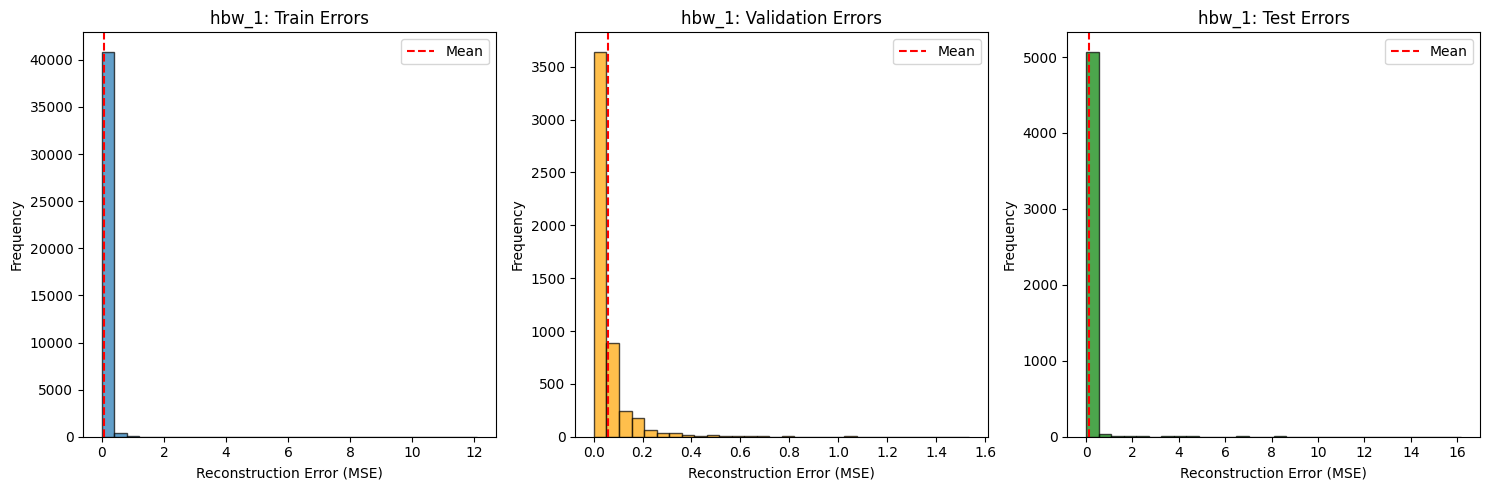

Resource: hbw_1
Dataset         Mean       Std    Median    95th %ile
----------  --------  --------  --------  -----------
Train       0.06069   0.111047  0.032991     0.200003
Validation  0.059194  0.09194   0.032777     0.188516
Test        0.112488  0.584031  0.033421     0.244959



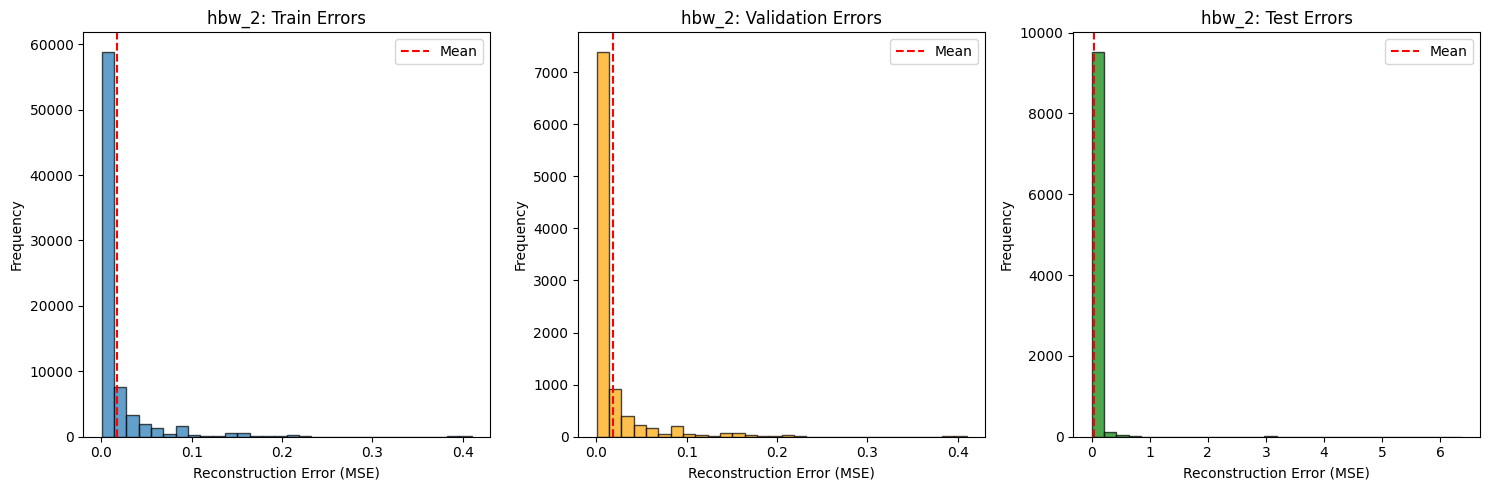

Resource: hbw_2
Dataset         Mean       Std    Median    95th %ile
----------  --------  --------  --------  -----------
Train       0.017472  0.037664  0.005017     0.085841
Validation  0.018     0.040039  0.004984     0.087257
Test        0.035459  0.211556  0.005452     0.111689



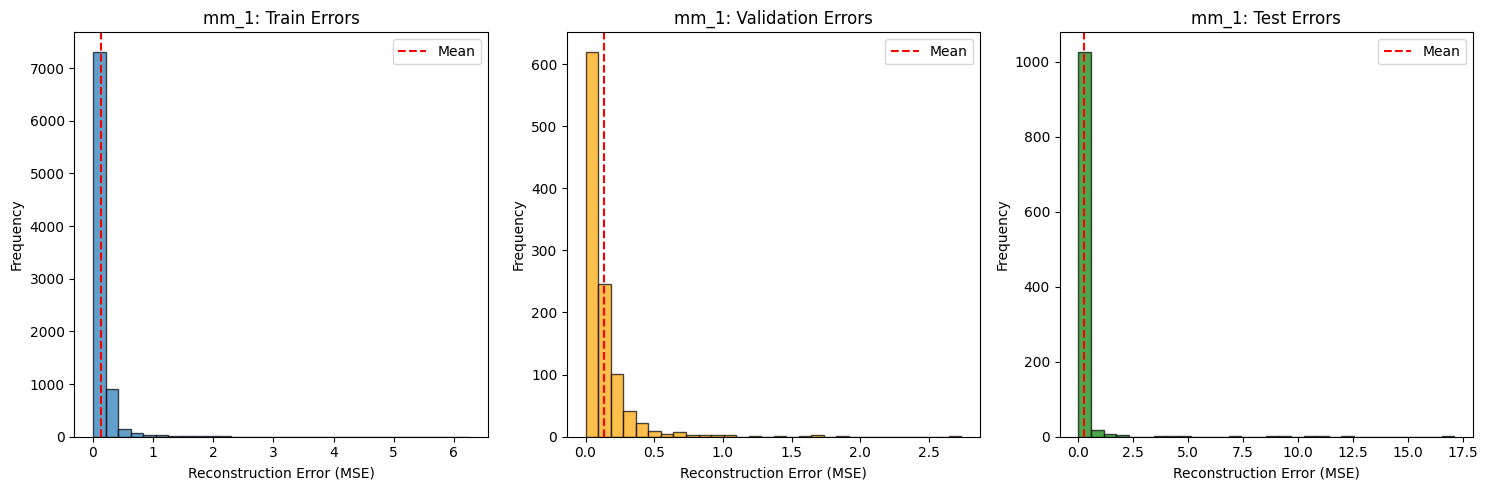

Resource: mm_1
Dataset         Mean       Std    Median    95th %ile
----------  --------  --------  --------  -----------
Train       0.130597  0.222208  0.073486     0.36917
Validation  0.131583  0.193457  0.073889     0.402309
Test        0.24219   1.03995   0.082595     0.501365



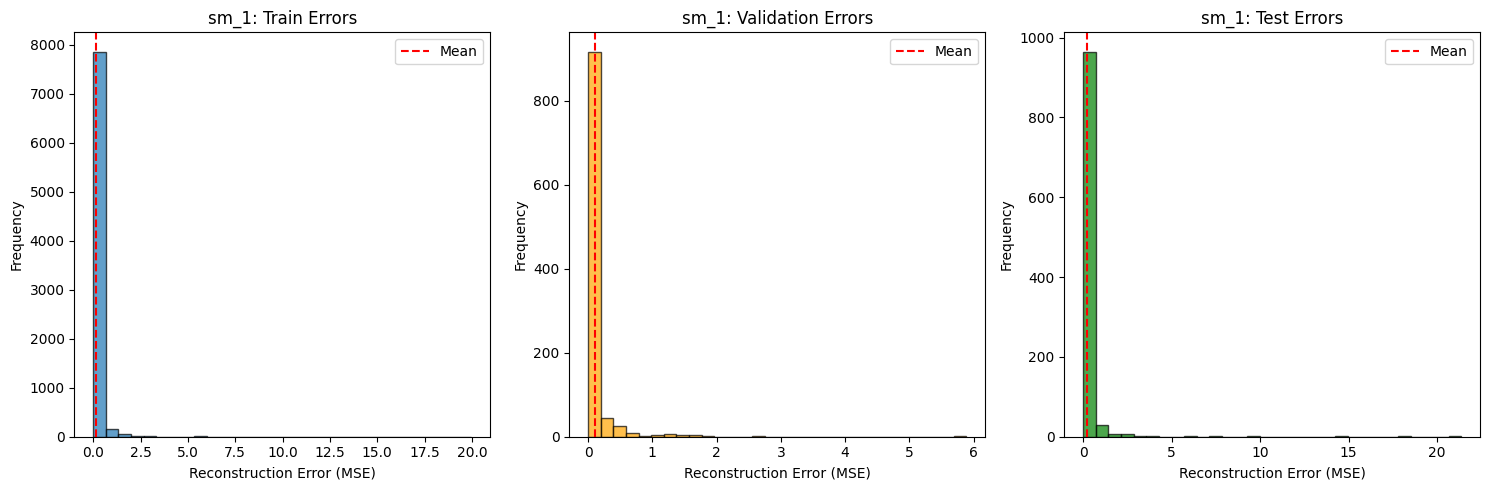

Resource: sm_1
Dataset         Mean       Std    Median    95th %ile
----------  --------  --------  --------  -----------
Train       0.121904  0.565292  0.027726     0.451814
Validation  0.101144  0.298101  0.028276     0.420932
Test        0.209758  1.14419   0.030566     0.724496



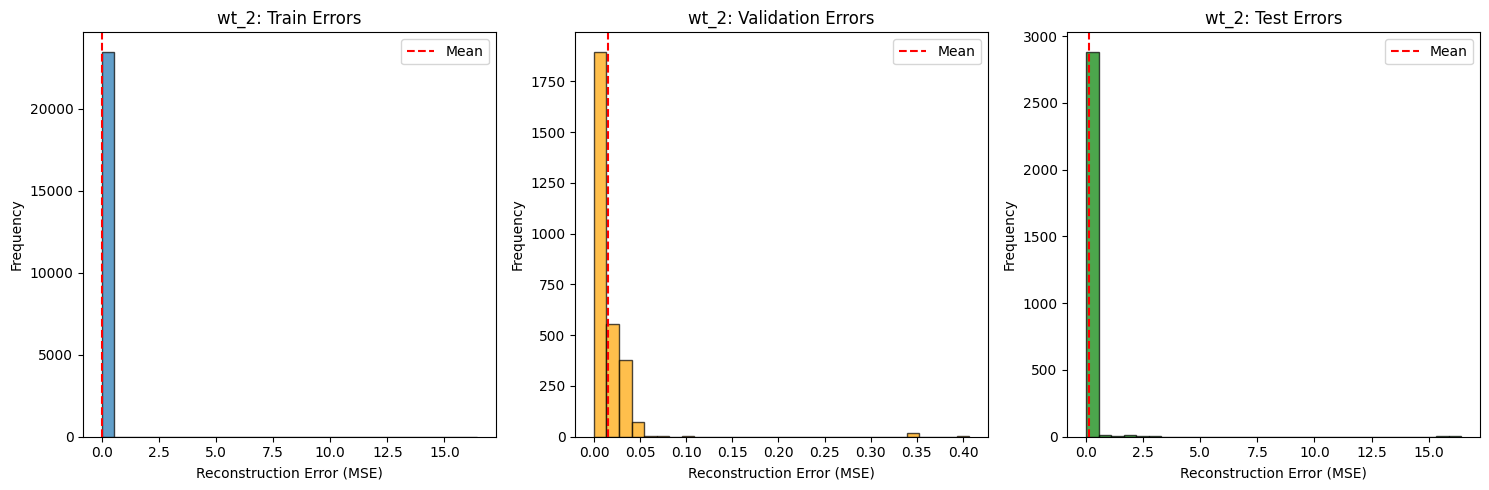

Resource: wt_2
Dataset         Mean       Std    Median    95th %ile
----------  --------  --------  --------  -----------
Train       0.022226  0.318114  0.006263     0.038775
Validation  0.014717  0.033806  0.006294     0.038489
Test        0.115888  1.09919   0.006508     0.043025



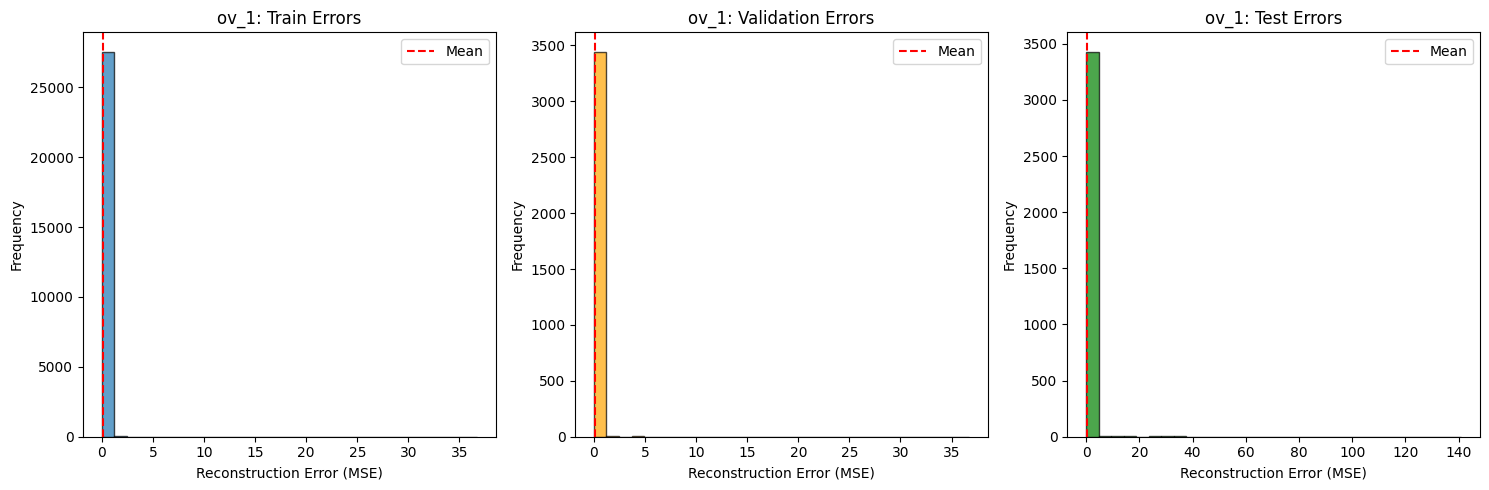

Resource: ov_1
Dataset         Mean       Std    Median    95th %ile
----------  --------  --------  --------  -----------
Train       0.077458  0.412227  0.037645     0.250737
Validation  0.085189  0.644388  0.037511     0.261582
Test        0.261163  3.12375   0.041913     0.375213



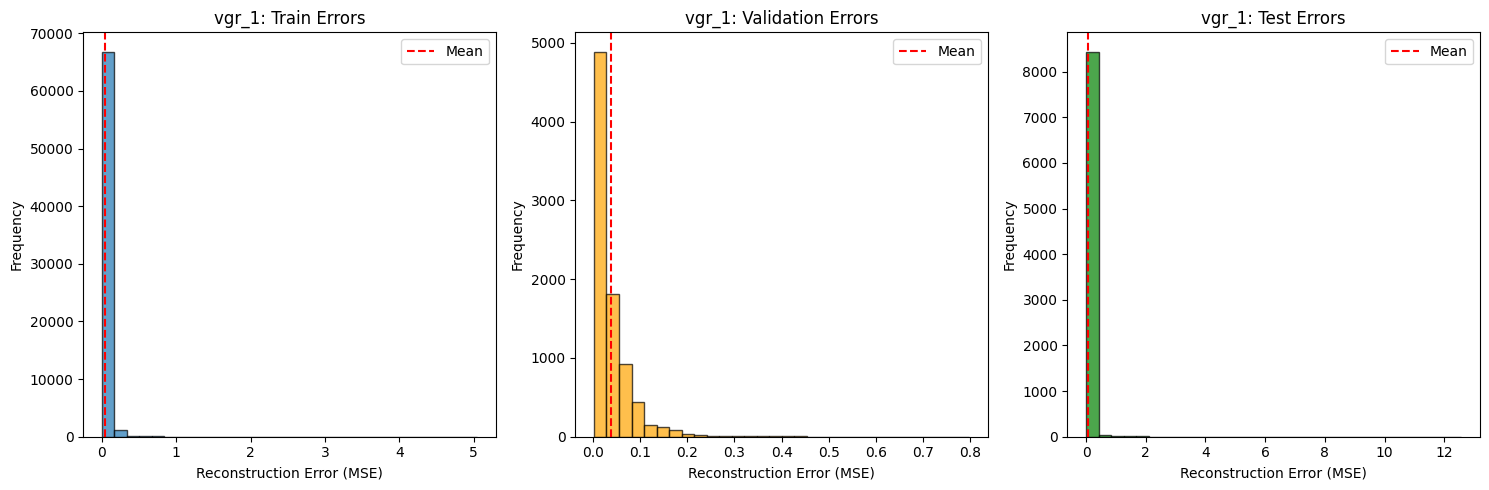

Resource: vgr_1
Dataset         Mean       Std    Median    95th %ile
----------  --------  --------  --------  -----------
Train       0.039894  0.062069  0.022815     0.11665
Validation  0.038912  0.046089  0.023044     0.113364
Test        0.06622   0.372533  0.023739     0.144666



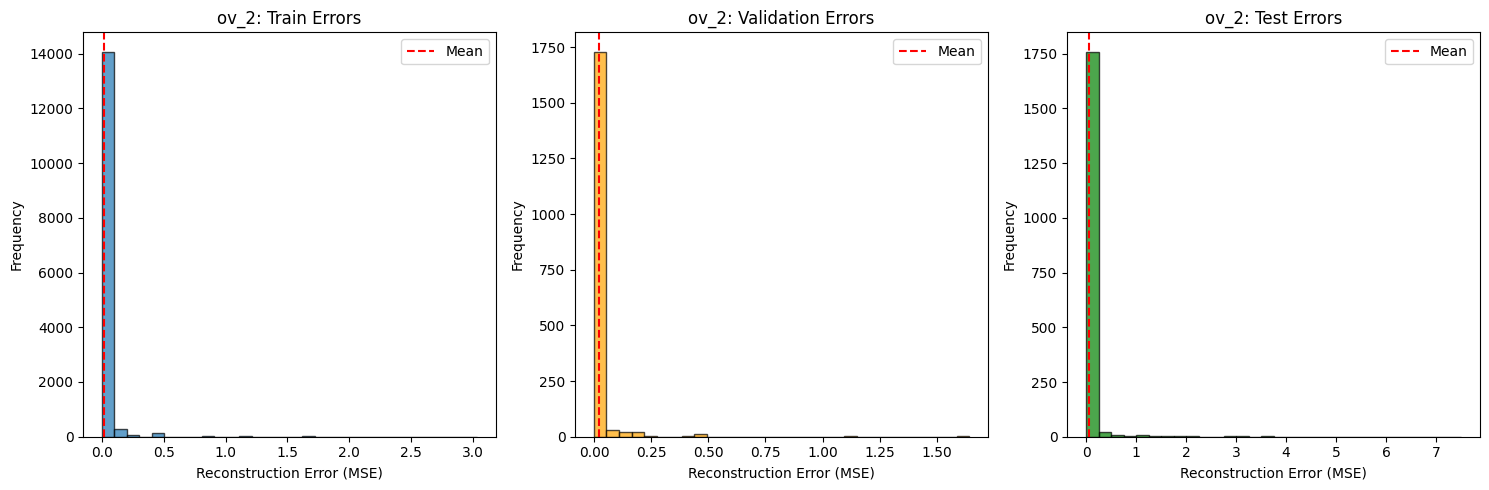

Resource: ov_2
Dataset         Mean       Std    Median    95th %ile
----------  --------  --------  --------  -----------
Train       0.020086  0.096064  0.002889     0.068845
Validation  0.020865  0.100511  0.002892     0.060847
Test        0.061005  0.357436  0.002965     0.153749



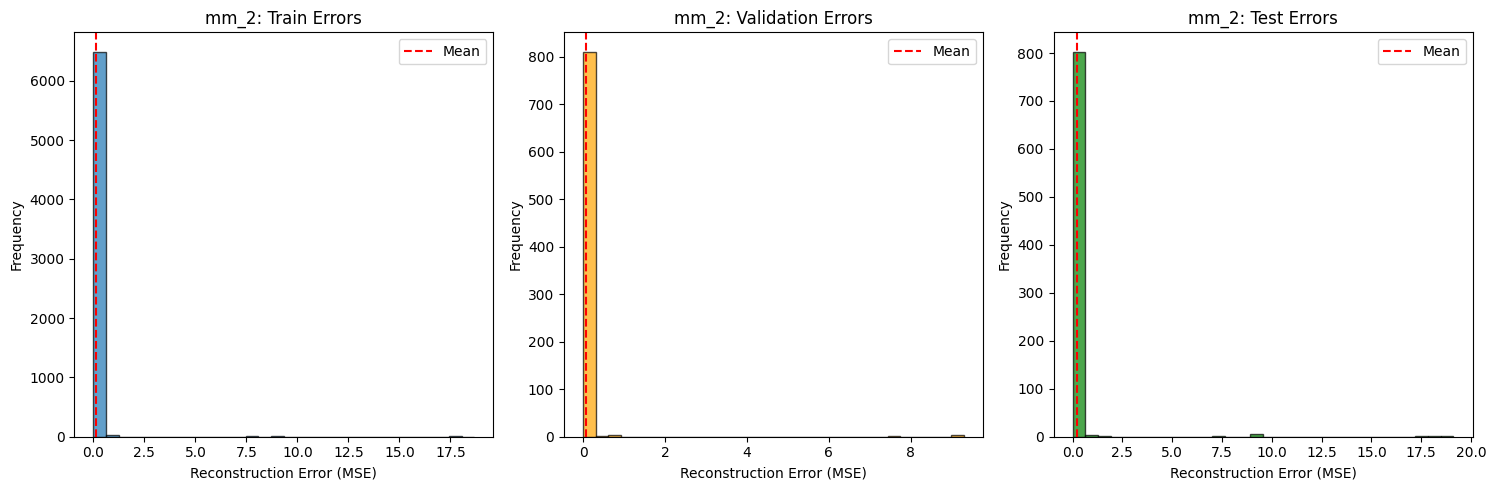

Resource: mm_2
Dataset         Mean       Std    Median    95th %ile
----------  --------  --------  --------  -----------
Train       0.118749  1.07611   0.005443     0.144953
Validation  0.079524  0.698688  0.005306     0.136761
Test        0.224926  1.65413   0.005299     0.168628



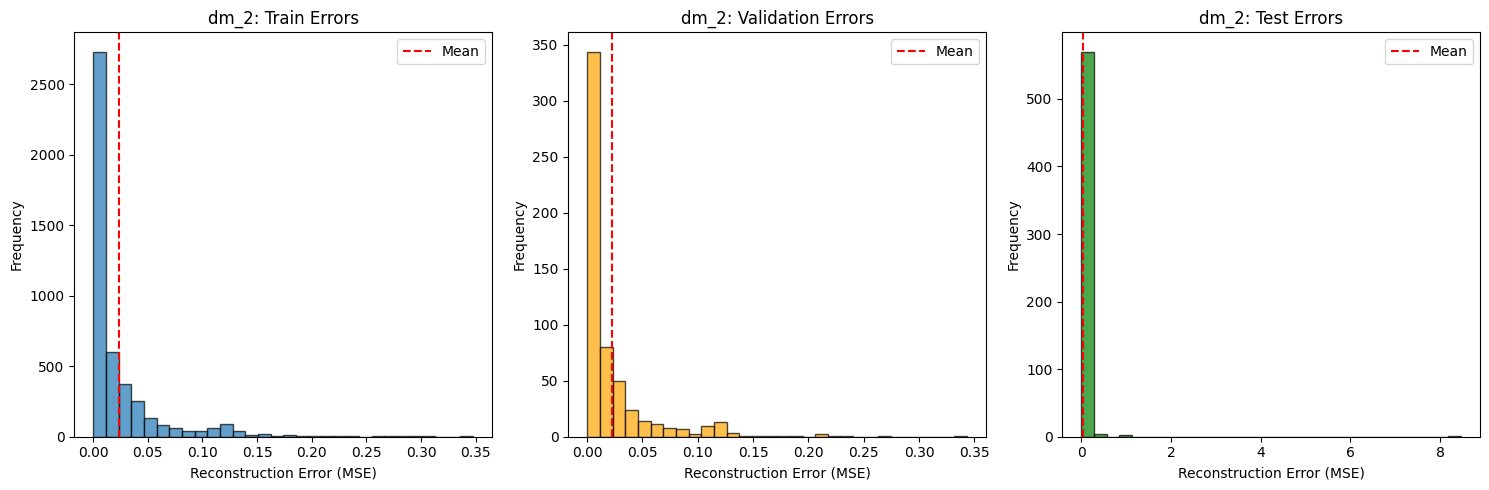

Resource: dm_2
Dataset         Mean       Std    Median    95th %ile
----------  --------  --------  --------  -----------
Train       0.023355  0.038269  0.006163     0.11406
Validation  0.022884  0.039203  0.005972     0.113757
Test        0.043618  0.358314  0.007209     0.120432



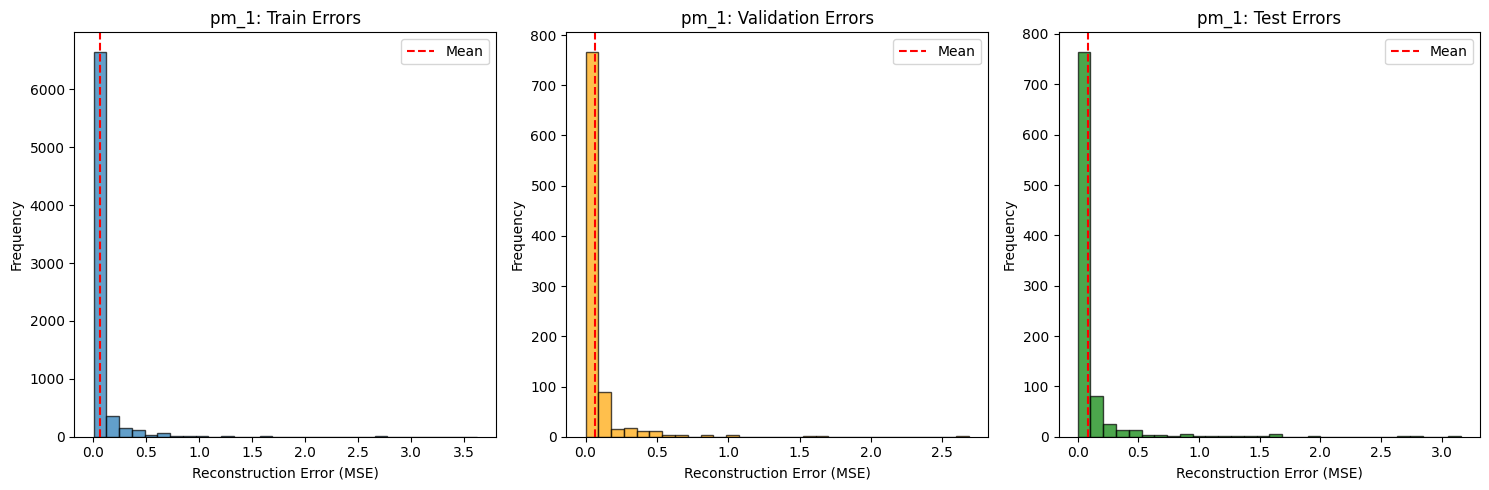

Resource: pm_1
Dataset         Mean       Std    Median    95th %ile
----------  --------  --------  --------  -----------
Train       0.058855  0.178862  0.011589     0.270124
Validation  0.063479  0.180638  0.012629     0.305744
Test        0.088475  0.272711  0.011673     0.417471



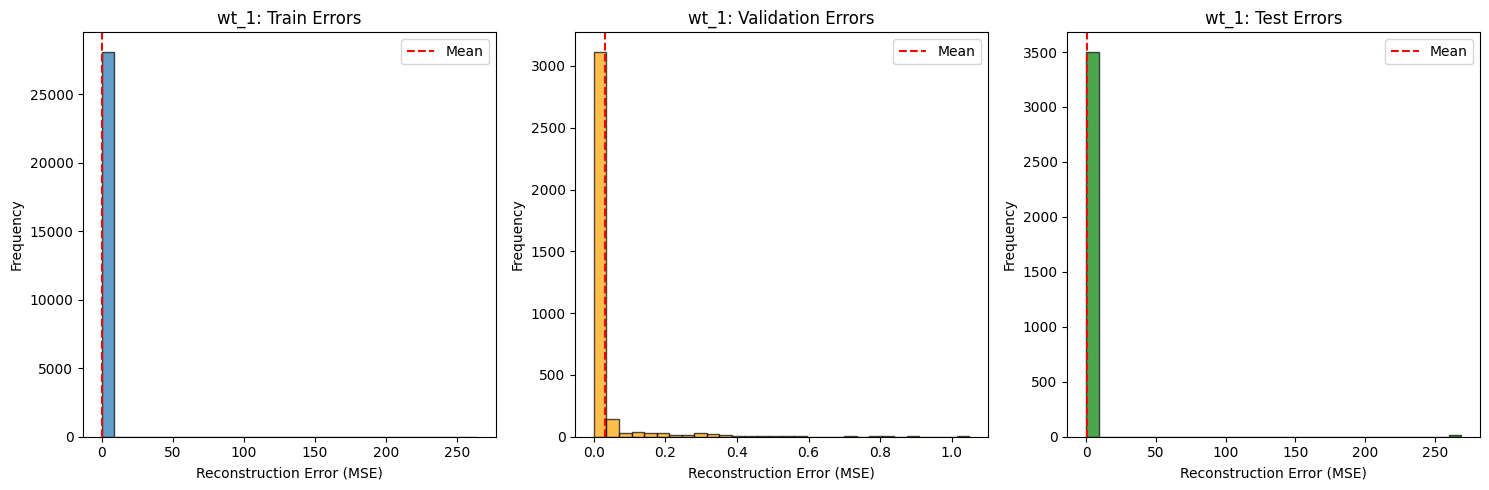

Resource: wt_1
Dataset         Mean        Std    Median    95th %ile
----------  --------  ---------  --------  -----------
Train       0.088051   3.86148   0.009564     0.155142
Validation  0.031076   0.086114  0.009774     0.158281
Test        0.975452  15.5395    0.00984      0.28619



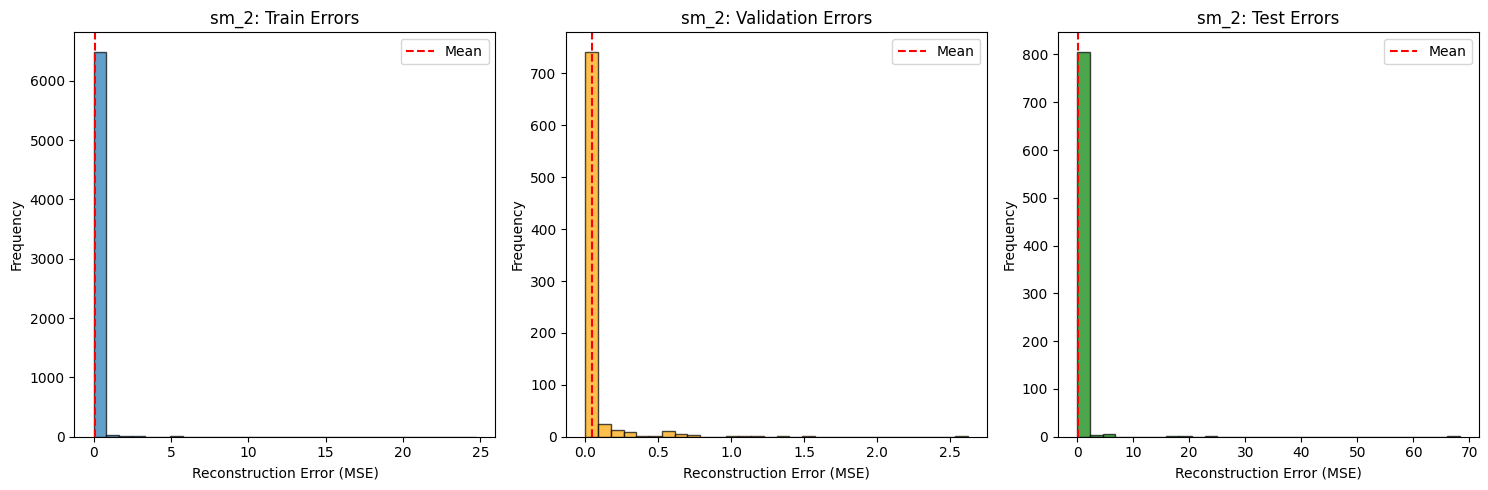

Resource: sm_2
Dataset         Mean       Std    Median    95th %ile
----------  --------  --------  --------  -----------
Train       0.063844  0.639404  0.004313     0.196003
Validation  0.049264  0.181534  0.00449      0.242971
Test        0.24839   2.73833   0.004244     0.267698



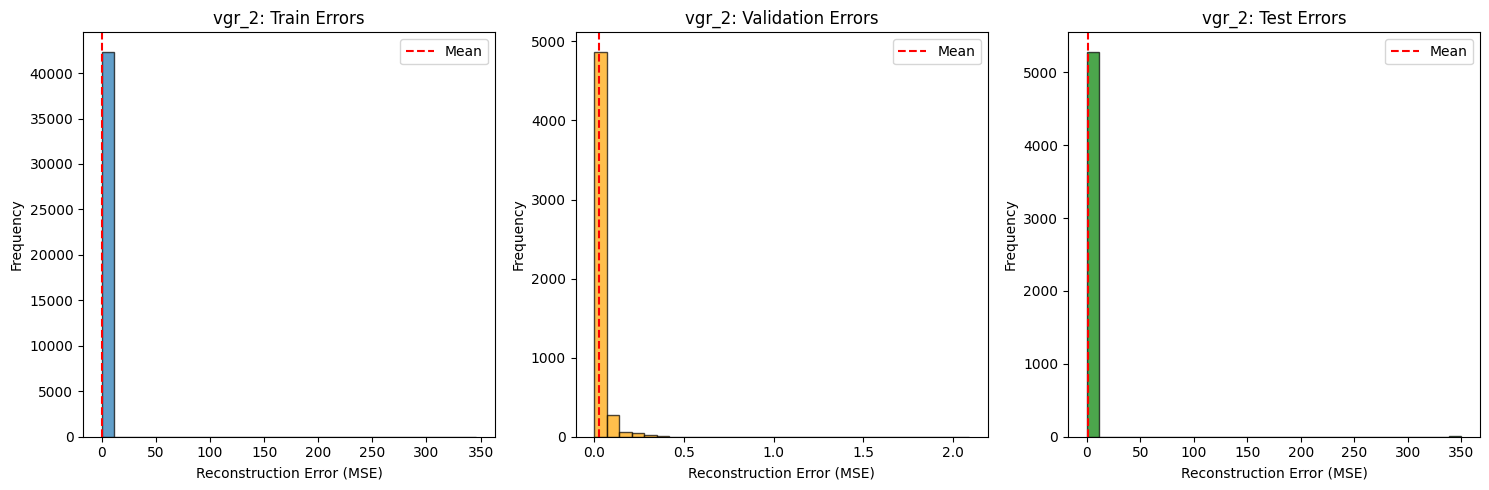

Resource: vgr_2
Dataset         Mean        Std    Median    95th %ile
----------  --------  ---------  --------  -----------
Train       0.064112   3.36446   0.012794     0.106634
Validation  0.028482   0.079285  0.012706     0.093149
Test        0.838358  16.5298    0.01301      0.163166



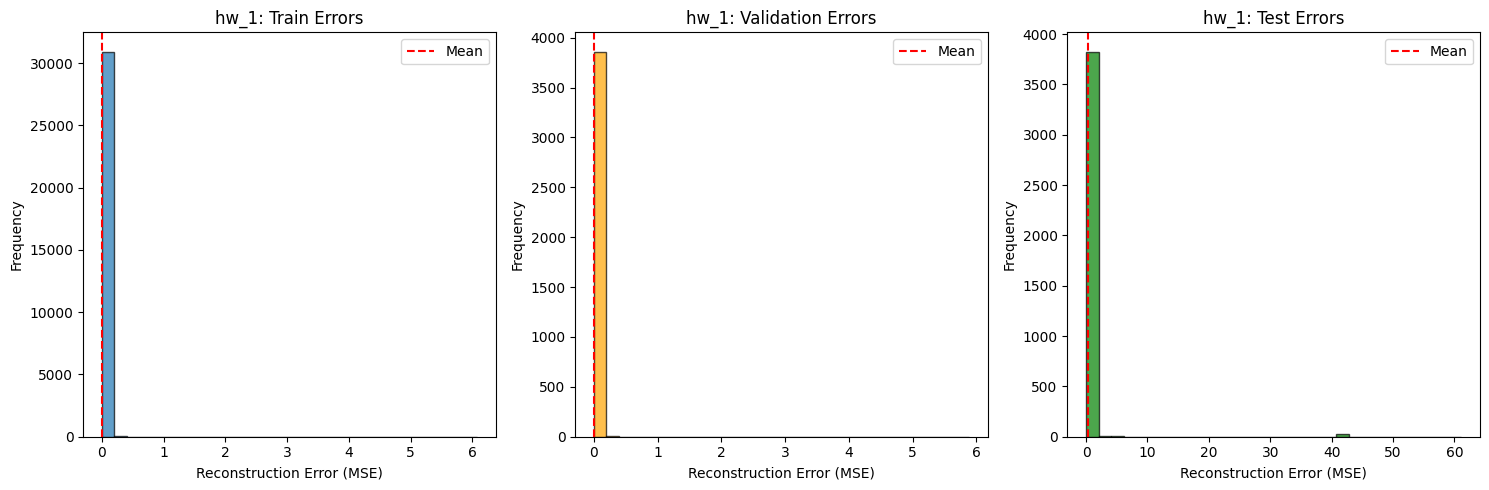

Resource: hw_1
Dataset         Mean       Std    Median    95th %ile
----------  --------  --------  --------  -----------
Train       0.004628  0.047508  0.00192      0.004712
Validation  0.007077  0.110248  0.001897     0.004712
Test        0.343373  3.62687   0.001952     0.021919



In [ ]:
# Generalization Analysis - Train vs Test Error Distribution
print(f"\n{'='*60}")
print("Generalization Analysis: Train vs Test Error Distribution")
print(f"{'='*60}\n")

for resource, data in all_results.items():
    # Get the model for this resource
    train_scaled = data["train_scaled"]
    val_scaled = data["val_scaled"]
    test_scaled = data["test_scaled"]
    reconstructions = data["ae_reconstructions"]

    # Convert to 2D numpy arrays for sklearn compatibility
    train_np = to_numpy_2d(train_scaled)
    val_np = to_numpy_2d(val_scaled)
    test_np = to_numpy_2d(test_scaled)
    recon_np = to_numpy_2d(reconstructions)

    # Reconstruct the original train/validation sets using the already available model pipeline.
    _, train_reconstructions, _ = detect_anomalies(
        train_scaled,
        val_scaled,
        train_scaled,
        data["scaling"],
        data["column_names"],
        resource,
        train_model=False,
        redo_hyperparameter_tuning=False,
        prints=False,
        test_scaled=train_scaled,
    )
    _, val_reconstructions, _ = detect_anomalies(
        train_scaled,
        val_scaled,
        val_scaled,
        data["scaling"],
        data["column_names"],
        resource,
        train_model=False,
        redo_hyperparameter_tuning=False,
        prints=False,
        test_scaled=val_scaled,
    )

    train_recon_np = to_numpy_2d(train_reconstructions)
    val_recon_np = to_numpy_2d(val_reconstructions)

    # Compute reconstruction errors (MSE per row)
    train_errors = np.mean((train_np - train_recon_np) ** 2, axis=1)
    val_errors = np.mean((val_np - val_recon_np) ** 2, axis=1)
    test_errors = np.mean((test_np - recon_np) ** 2, axis=1)

    # Plot histograms
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].hist(train_errors, bins=30, alpha=0.7, edgecolor="black")
    axes[0].set_title(f"{resource}: Train Errors")
    axes[0].set_xlabel("Reconstruction Error (MSE)")
    axes[0].set_ylabel("Frequency")
    axes[0].axvline(np.mean(train_errors), color="r", linestyle="--", label="Mean")
    axes[0].legend()

    axes[1].hist(val_errors, bins=30, alpha=0.7, color="orange", edgecolor="black")
    axes[1].set_title(f"{resource}: Validation Errors")
    axes[1].set_xlabel("Reconstruction Error (MSE)")
    axes[1].set_ylabel("Frequency")
    axes[1].axvline(np.mean(val_errors), color="r", linestyle="--", label="Mean")
    axes[1].legend()

    axes[2].hist(test_errors, bins=30, alpha=0.7, color="green", edgecolor="black")
    axes[2].set_title(f"{resource}: Test Errors")
    axes[2].set_xlabel("Reconstruction Error (MSE)")
    axes[2].set_ylabel("Frequency")
    axes[2].axvline(np.mean(test_errors), color="r", linestyle="--", label="Mean")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    # Print statistics
    stats_table = [
        ["Train", f"{np.mean(train_errors):.6f}", f"{np.std(train_errors):.6f}", f"{np.median(train_errors):.6f}", f"{np.percentile(train_errors, 95):.6f}"],
        ["Validation", f"{np.mean(val_errors):.6f}", f"{np.std(val_errors):.6f}", f"{np.median(val_errors):.6f}", f"{np.percentile(val_errors, 95):.6f}"],
        ["Test", f"{np.mean(test_errors):.6f}", f"{np.std(test_errors):.6f}", f"{np.median(test_errors):.6f}", f"{np.percentile(test_errors, 95):.6f}"],
    ]

    print(f"Resource: {resource}")
    print(tabulate.tabulate(stats_table, headers=["Dataset", "Mean", "Std", "Median", "95th %ile"]))
    print()

## Additional Analyses for Thesis
The following sections extend the analysis with interpretable diagnostics that are useful in smart factory anomaly detection.

## Error Separation (Autoencoder)
This section compares reconstruction error distributions for normal and anomalous rows. A larger separation indicates that anomalies are easier to distinguish from normal behavior.

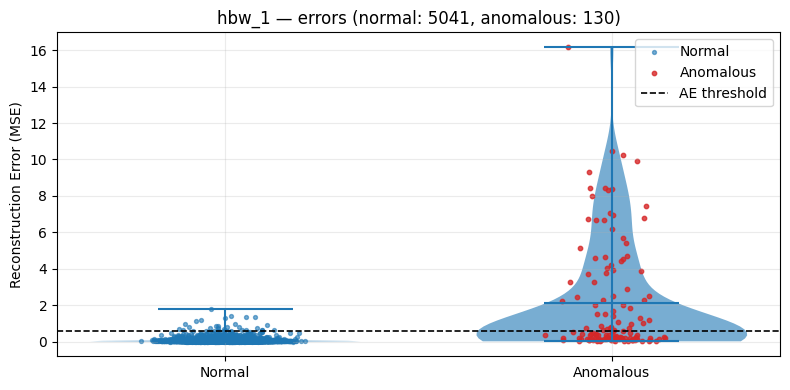

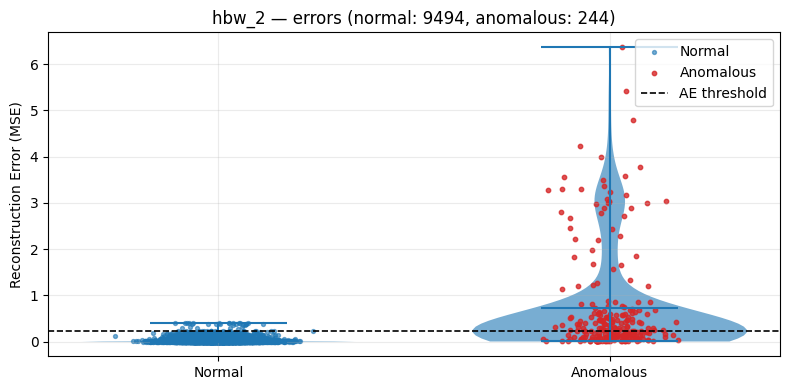

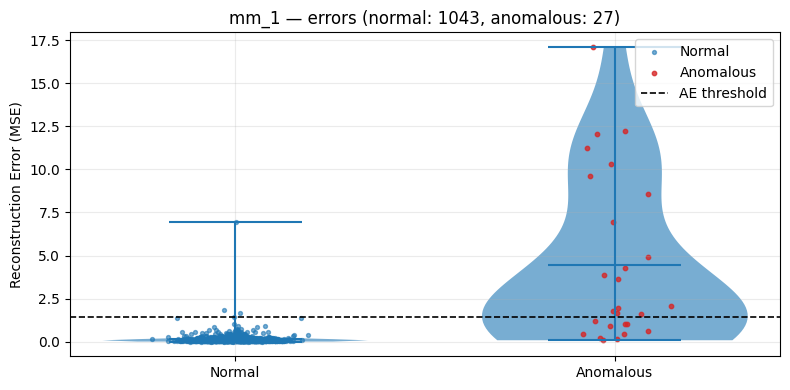

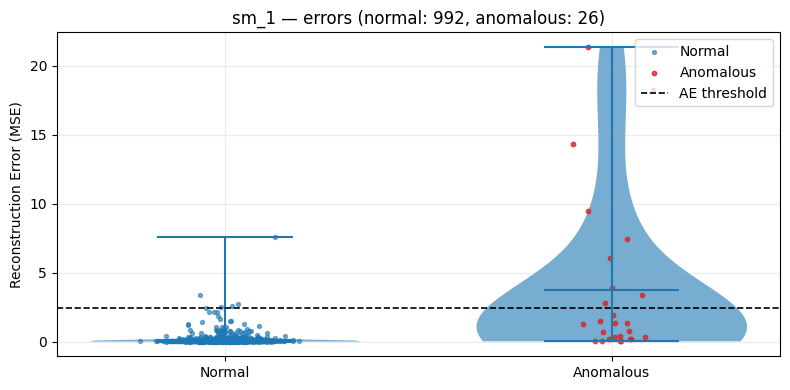

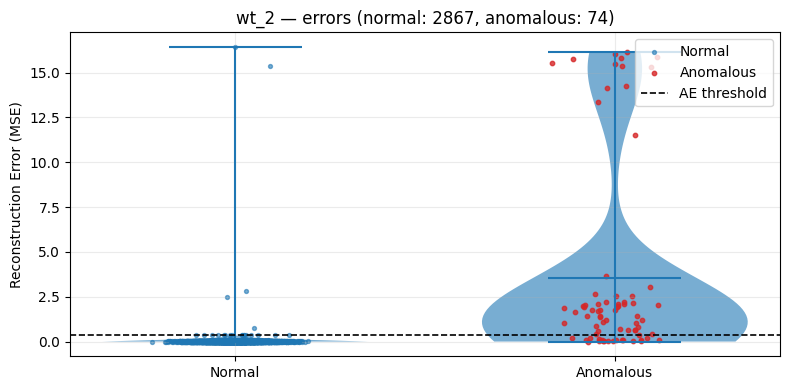

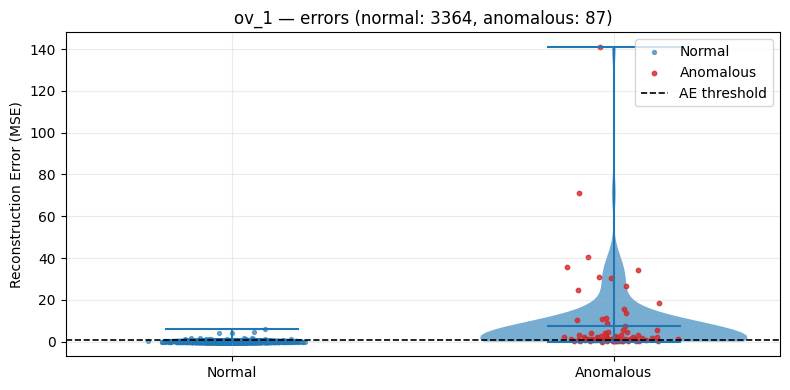

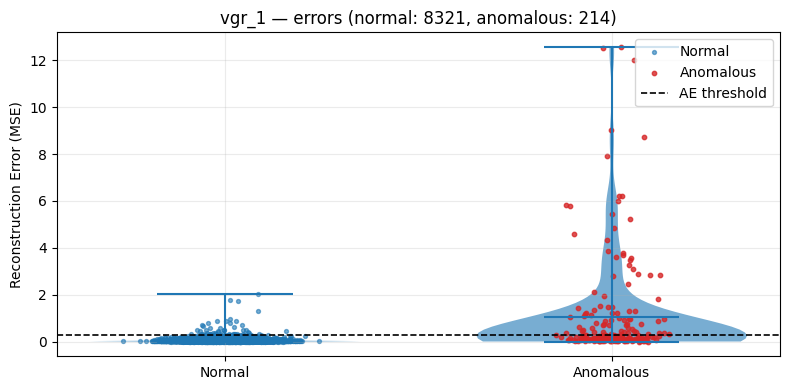

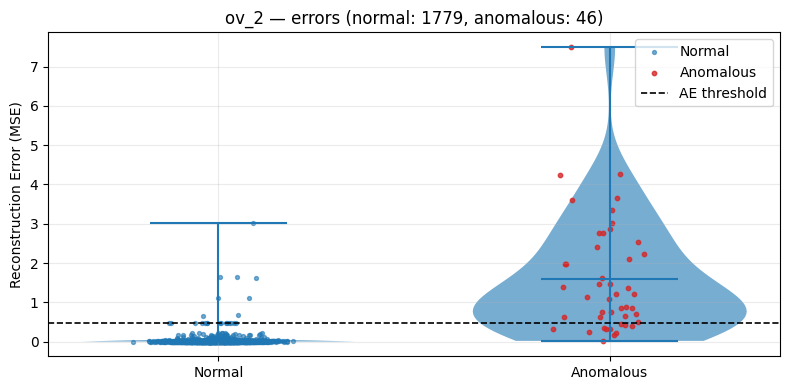

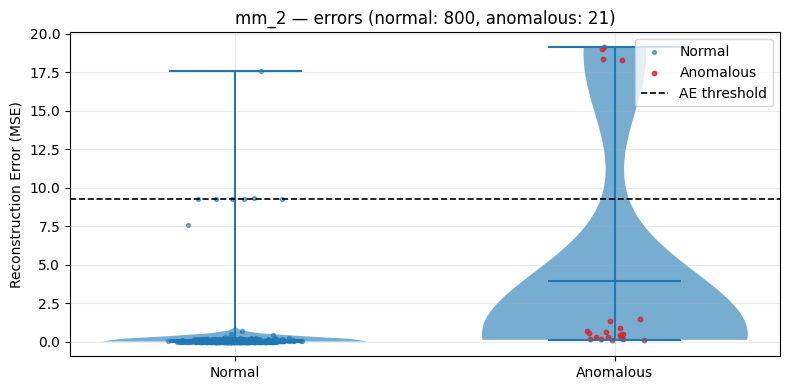

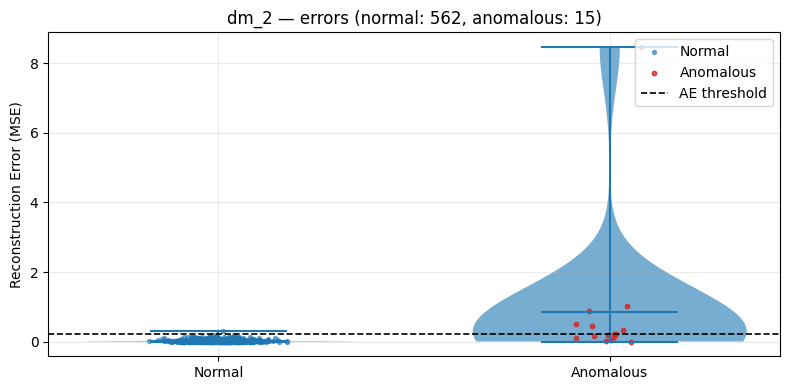

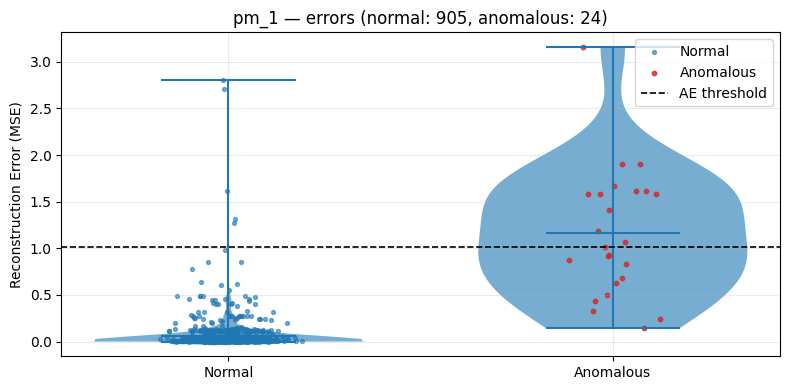

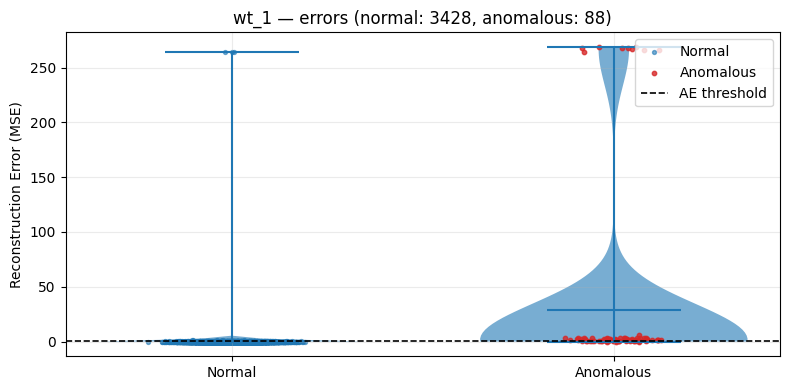

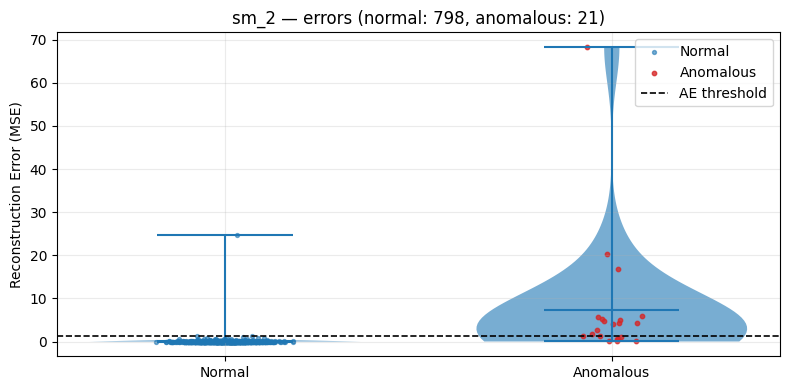

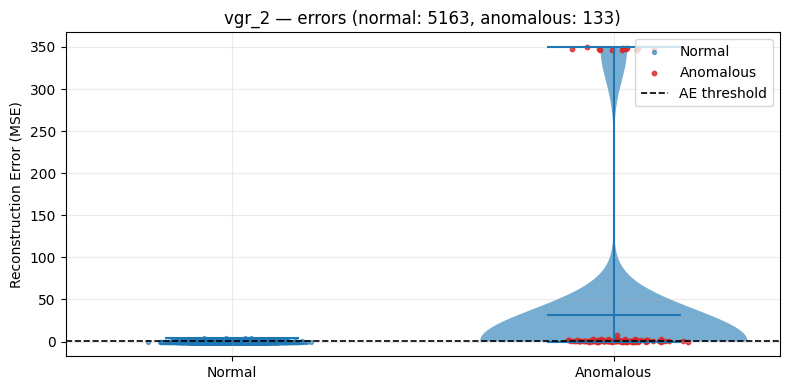

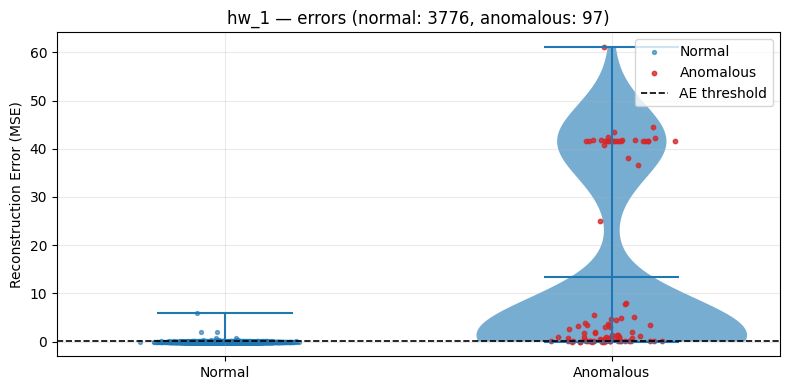

In [85]:
# Per-resource reconstruction error distributions with AE threshold and actual-anomaly labels
for resource, data in all_results.items():
    test_np = to_numpy_2d(data["test_anomalous"])
    recon_np = to_numpy_2d(data["ae_reconstructions"])
    if test_np.size == 0:
        continue

    errors = np.mean((test_np - recon_np) ** 2, axis=1)
    labels = np.zeros(len(errors), dtype=int)
    for row_id in data.get("anomalous_values", {}).keys():
        try:
            idx = int(row_id)
        except Exception:
            continue
        if 0 <= idx < len(labels):
            labels[idx] = 1

    normal_errors = errors[labels == 0]
    anomaly_errors = errors[labels == 1]

    # Prepare violin data (only include non-empty groups)
    groups = []
    xticks = []
    positions = []
    if normal_errors.size > 0:
        groups.append(normal_errors)
        xticks.append("Normal")
        positions.append(1)
    if anomaly_errors.size > 0:
        groups.append(anomaly_errors)
        xticks.append("Anomalous")
        positions.append(2 if len(positions) == 0 else 2)

    fig, ax = plt.subplots(figsize=(8, 4))
    if groups:
        parts = ax.violinplot(groups, positions=positions, widths=0.7, showmeans=True, showextrema=True)
        for pc in parts["bodies"]:
            pc.set_alpha(0.6)

    # Jittered scatter of all points so distribution and outliers are visible
    rng = np.random.default_rng(RANDOM_SEED if "RANDOM_SEED" in globals() else None)
    if normal_errors.size > 0:
        xs = rng.normal(1, 0.06, size=normal_errors.size)
        ax.scatter(xs, normal_errors, s=8, alpha=0.6, color="C0", label="Normal")
    if anomaly_errors.size > 0:
        xs = rng.normal(2, 0.06, size=anomaly_errors.size)
        ax.scatter(xs, anomaly_errors, s=10, alpha=0.8, color="C3", label="Anomalous")

    # AE threshold if available
    thr = data.get("ae_threshold", None)
    if thr is not None and not (isinstance(thr, float) and np.isnan(thr)):
        ax.axhline(float(thr), color="k", linestyle="--", linewidth=1.2, label="AE threshold")

    ax.set_xticks([1, 2][: len(xticks)])
    ax.set_xticklabels(xticks)
    ax.set_ylabel("Reconstruction Error (MSE)")
    n_norm = normal_errors.size
    n_anom = anomaly_errors.size
    ax.set_title(f"{resource} — errors (normal: {n_norm}, anomalous: {n_anom})")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


## Recall at Top-K Errors
This analysis measures how many true anomalies appear among the highest reconstruction errors. It reflects how well the model supports a triage workflow where only the top few cases are investigated.

In [86]:
# Recall at top-k percent of highest reconstruction errors
k_percents = [0.5, 1, 2, 5, 10]
recall_rows = []

combined_errors = []
combined_labels = []

for resource, data in all_results.items():
    test_np = to_numpy_2d(data["test_anomalous"])
    recon_np = to_numpy_2d(data["ae_reconstructions"])
    errors = np.mean((test_np - recon_np) ** 2, axis=1)
    labels = _labels_from_anomalies(len(errors), data["anomalous_values"])

    combined_errors.append(errors)
    combined_labels.append(labels)

    sorted_idx = np.argsort(errors)[::-1]
    total_anomalies = int(labels.sum())

    row = [resource]
    for k_percent in k_percents:
        k_count = max(1, int(np.ceil(len(errors) * (k_percent / 100))))
        top_k = sorted_idx[:k_count]
        recall_k = (int(labels[top_k].sum()) / total_anomalies) if total_anomalies > 0 else 0
        row.append(f"{recall_k:.3f}")

    recall_rows.append(row)

combined_errors = np.concatenate(combined_errors) if combined_errors else np.array([])
combined_labels = np.concatenate(combined_labels) if combined_labels else np.array([])

if combined_errors.size > 0:
    sorted_idx = np.argsort(combined_errors)[::-1]
    total_anomalies = int(combined_labels.sum())

    row = ["ALL"]
    for k_percent in k_percents:
        k_count = max(1, int(np.ceil(len(combined_errors) * (k_percent / 100))))
        top_k = sorted_idx[:k_count]
        recall_k = (int(combined_labels[top_k].sum()) / total_anomalies) if total_anomalies > 0 else 0
        row.append(f"{recall_k:.3f}")

    recall_rows.append(row)

headers = ["Resource"] + [f"Recall@{k}%" for k in k_percents]
print(tabulate.tabulate(recall_rows, headers=headers))

NameError: name '_labels_from_anomalies' is not defined

## Feature Contribution by Reconstruction Error
This section highlights sensors with the largest error increase on anomalous rows compared to normal rows. It offers a simple, interpretable view of which signals drive detection per resource.

In [ ]:
# Feature contribution based on per-column reconstruction error differences
top_n_features = 5

for resource, data in all_results.items():
    test_np = to_numpy_2d(data["test_anomalous"])
    recon_np = to_numpy_2d(data["ae_reconstructions"])
    per_col_errors = (test_np - recon_np) ** 2

    labels = _labels_from_anomalies(len(per_col_errors), data["anomalous_values"])
    anomaly_idx = np.where(labels == 1)[0]
    normal_idx = np.where(labels == 0)[0]

    if anomaly_idx.size == 0 or normal_idx.size == 0:
        print(f"{resource}: skipped (not enough anomalies or normal rows)")
        continue

    anomaly_mean = np.mean(per_col_errors[anomaly_idx], axis=0)
    normal_mean = np.mean(per_col_errors[normal_idx], axis=0)
    diff = anomaly_mean - normal_mean

    top_idx = np.argsort(diff)[::-1][:top_n_features]

    rows = []
    for idx in top_idx:
        rows.append([
            str(data["column_names"][idx]),
            f"{float(anomaly_mean[idx]):.6f}",
            f"{float(normal_mean[idx]):.6f}",
            f"{float(diff[idx]):.6f}",
        ])

    print(f"\nTop {top_n_features} features by anomaly-normal error gap for {resource}")
    print(tabulate.tabulate(rows, headers=[
        "Column",
        "Mean Anomaly Error",
        "Mean Normal Error",
        "Difference",
    ]))


Top 5 features by anomaly-normal error gap for hbw_1
Column                                                                                                                                Mean Anomaly Error    Mean Normal Error    Difference
----------------------------------------------------------------------------------------------------------------------------------  --------------------  -------------------  ------------
http://iot.uni-trier.de/FTOnto#BMX055_Pi_1_Gyroscope_2_http://iot.uni-trier.de/FTOnto#HBW_1_Crane_Jib_Rotation_1                                23.4587              0.062873      23.3958
http://iot.uni-trier.de/FTOnto#BMX055_Pi_1_Gyroscope_2_http://iot.uni-trier.de/FTOnto#HBW_1_Crane_Jib_Rotation_0                                16.2115              0.1793        16.0322
http://iot.uni-trier.de/FTOnto#BMX055_Pi_1_Gyroscope_2_http://iot.uni-trier.de/FTOnto#HBW_1_Crane_Jib_Rotation_2                                13.2235              0.187869      13.0357
http://io